<div style="border-bottom:2px solid #0077c8;padding:12px 0 24px;margin-bottom:24px;">
<p style="color:#0077c8;letter-spacing:.1em;font-size:12px;margin-top:24px;">DSPRO2 · TEAM 6 · RENTLENS</p>
<h1 style="font-family:'Arial Narrow',sans-serif;font-weight:800;line-height:1.05;">QUALITY-OF-LIFE INDEX<br>FOR SWISS RENTAL APARTMENTS</h1>
<p style="font-size:17px;color:#153652;margin-top:8px;">A composite indicator after the OECD/JRC Handbook, built from official geodata and validated without ground truth (RQ4)</p>
<p>Elias Martinelli · Timo Schlumpf</p>
</div>

## 0. Why a Quality-of-Life Index, and what this notebook delivers

A rent alone does not tell a tenant whether an apartment is a good place to live. The project
proposal therefore makes the **Quality-of-Life Index (QoLI)** the second core deliverable
(**P2**), next to the listing text (P1) and the spatial model (P3). The ML pipeline notebook
(`dspro2_ml_pipeline.ipynb`, section 22) contained a two-dimension prototype built from the
DSPRO1 enrichment (public transport and roof solar class, available for only half of the objects).
This notebook replaces that prototype with the index **as specified in the proposal**:

| Proposal requirement | Where | Status in this notebook |
|---|---|---|
| Composite indicator after the OECD/JRC *Handbook on Constructing Composite Indicators* and the OECD Better Life Index | whole notebook, sections follow the handbook steps | done |
| Min–max normalisation, equal weights within dimensions, user-defined weights across dimensions | 9–10 | done (winsorised min–max on all inhabited hectares) |
| Core index: public-transport quality, road and rail noise, OSM accessibility (Walk-Score-style decay), green share | 2, 6 | done, all four dimensions for every object |
| Extended index, *if time permits*: air quality, sunshine, tax burden, vacancy | 2, 6, 10 | done as a second, clearly separated index |
| BAFU L<sub>r,Tag</sub>/L<sub>r,Nacht</sub> against the LSV impact thresholds (60/50 dB(A)) | 7 | done, road and rail assessed separately |
| WHO guideline (53 dB L<sub>den</sub>) only after a documented approximation | 7 | done, approximation stated, descriptive only |
| RQ4: rank stability under weight perturbation | 11 | done (Dirichlet, plus normalisation, aggregation and indicator choices) |
| RQ4: convergent validity with independent municipal indicators (BFS City Statistics; BILANZ/IAZI if access) | 12 | done for BFS data; BILANZ/IAZI not accessible (reported as open) |
| Value score: quality of life relative to price | 14 | done (descriptive, within peer groups) |
| Map: QoLI and value score by canton > district > municipality, cells with < 20 listings hidden | 15 | done; listing-free QoLI is shown everywhere, the price-based value score only above the minimum count |
| Datasheet: every dataset with source, terms and reference year | 3 | done (generated table) |
| MLflow: QoLI weights, aggregation method, rank stability, external correlations | 16 | done |

**Design decision: the reference population is Switzerland, not our listings.** All indicators
are computed for the ~347,000 inhabited hectares of Switzerland (BFS STATPOP 2021) *and* for every
rental object. Normalisation bounds come from the hectares, so the index of an apartment does not
depend on which listings happened to be scraped, every municipality gets a population-weighted
score (convergent validity on ~2,100 units instead of a few dozen), and the app can score any new
address on the same scale.

**How to run.** Kernel *DSPRO2 (uv, Python 3.12)* from the `dspro2` uv project (see the README).
All logic lives in `rentml.qoli`, `rentml.qoli_sources`, `rentml.qoli_layers`,
`rentml.qoli_municipal`, `rentml.qoli_robustness` and `rentml.amenities`; the notebook only
orchestrates, plots and interprets. The first run downloads about 1.8 GB of open data into
`data/external/qoli/` (cached afterwards) and takes about 10 minutes; later runs reuse
the cached hectare indicators.

| Variable | Values | Effect |
|---|---|---|
| `DSPRO2_RUN_MODE` | `full` (default), `fast` | `fast` = fewer Dirichlet draws and bootstrap resamples |
| `DSPRO2_DATA_SOURCE` | `auto` (default), `db`, `csv` | listings from the database (with descriptions) or the DSPRO1 CSV exports |
| `DSPRO2_QOLI_REFRESH` | `0` (default), `1` | recompute the cached hectare indicators |

---

## 1. Setup and Reproducibility

In [1]:
import json
import logging
import os
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import display
from matplotlib.colors import TwoSlopeNorm
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore", message="IProgress not found")

In [2]:
from rentml import geo
from rentml.amenities import fetch_osm_amenities
from rentml.cleaning import domain_filter, price_per_sqm_outliers, regime_split
from rentml.config import (
    LSV_THRESHOLDS_DBA,
    MIN_MAP_CELL,
    RANDOM_STATE,
    SB3D_VERSION,
    ProjectPaths,
    load_env,
)
from rentml.data import fix_schema, load_listings, text_coverage
from rentml.dedup import assign_object_ids, collapse_objects
from rentml.evaluation import holm_correction
from rentml.extraction import extract_frame, rule_based_extract
from rentml.plotting import COLORS, apply_plot_style, save_fig, to_markdown
from rentml.qoli import (
    Indicator,
    aggregate,
    convergent_validity,
    lsv_exceedance,
    minmax_normalize,
    normalization_bounds,
    value_score,
    weight_sensitivity,
)
from rentml.qoli_layers import (
    LAYER_KEYS,
    WHO_LDEN_DB,
    QoliLayers,
    apply_quiet_noise,
    green_share,
    lden_from_lr,
    load_hectares,
)
from rentml.qoli_municipal import (
    city_statistics,
    fetch_commune_correspondence,
    fetch_sdmx_csv,
    load_tax_burden,
    remap_municipalities,
    vacancy_rates,
)
from rentml.qoli_robustness import (
    dimension_consistency,
    geometric_aggregate,
    leave_one_out,
    percentile_normalize,
    rank_comparison,
    weighted_quantile,
    weighted_unit_scores,
)
from rentml.qoli_sources import SOURCES, fetch_sources, source_table
from rentml.text import anonymize_series
from rentml.tracking import Tracker

In [3]:
RUN_MODE = os.environ.get("DSPRO2_RUN_MODE", "full")
DATA_SOURCE = os.environ.get("DSPRO2_DATA_SOURCE", "auto")
REFRESH = os.environ.get("DSPRO2_QOLI_REFRESH", "0") == "1"
FAST = RUN_MODE == "fast"
BUDGET = {"sensitivity_draws": 100 if FAST else 500}
SESSION_ID = pd.Timestamp.now().strftime("%Y%m%d-%H%M%S")

paths = ProjectPaths.discover()
paths.ensure()
QOLI_DIR = paths.data_external / "qoli"
APP_DIR = paths.project_root / "data" / "app"
ENV_FILES = load_env(paths) if DATA_SOURCE != "csv" else []

logging.basicConfig(level=logging.WARNING, format="%(levelname)s %(name)s: %(message)s")
for noisy in ("mlflow", "alembic", "urllib3", "matplotlib", "fontTools", "rasterio"):
    logging.getLogger(noisy).setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", module="mlflow")

apply_plot_style()
tracker = Tracker(paths.mlruns, experiment="dspro2-rent-fast" if FAST else "dspro2-rent")
km_fmt = plt.FuncFormatter(lambda v, _: f"{v / 1000:,.0f}".replace(",", "'"))
print(f"RUN_MODE={RUN_MODE}  DATA_SOURCE={DATA_SOURCE}  REFRESH={REFRESH}  SESSION_ID={SESSION_ID}")
print(f"tracker backend={tracker.backend}  |  open data cache: {QOLI_DIR}")

RUN_MODE=full  DATA_SOURCE=csv  REFRESH=False  SESSION_ID=20261002-222930
tracker backend=mlflow  |  open data cache: /home/sa_linux/code/Elias-Martinelli/dspro1/data/external/qoli


---

## 2. Theoretical Framework: What "Quality of Life" Means Here

The OECD/JRC handbook starts with a definition of the phenomenon and a selection rule for the
indicators. **Definition:** the QoLI measures the *quality of the location* of a home for
everyday life: how well it is connected, how quiet and green it is, and how easily daily needs
can be met on foot. It does **not** measure the apartment itself (size, condition, view: these
are rent features in the price model) and not the price (that is the value score in section 14).

**Selection rules.** An indicator must (1) be available nationwide at the address or hectare
level from an official or open source, (2) have an unambiguous direction (more is better or
worse for residents), (3) be reproducible from a dated, citable dataset, and (4) not be derived
from listing prices, so that the index can later be compared with rents without circularity.

| Dimension | Indicator | Direction | Source (reference) | Index |
|---|---|---|---|---|
| transport | public-transport quality class (A = 4 … D = 1, none = 0) | higher is better | ARE ÖV-Güteklassen (timetable 2026) | core |
| transport | distance to the nearest classified stop (log) | lower is better | ARE stops with category I–V | core |
| noise | road + rail L<sub>r,Tag</sub>, energetic sum at the most exposed façade | lower is better | BAFU sonBASE (2021) | core |
| noise | road + rail L<sub>r,Nacht</sub>, energetic sum | lower is better | BAFU sonBASE (2021) | core |
| amenities | Walk-Score-style accessibility of 7 everyday categories (candidate) | higher is better | OpenStreetMap (ODbL) | core |
| green | share of green and wooded hectares within 300 m | higher is better | BFS Arealstatistik (2013–2020) | core |
| green | accessibility of OSM parks (same decay; candidate) | higher is better | OpenStreetMap | core |
| air | NO₂ annual mean | lower is better | BAFU PolluMap (2025) | extended |
| air | PM2.5 annual mean | lower is better | BAFU PolluMap (2025) | extended |
| sunshine | relative sunshine duration, normal 1991–2020 | higher is better | MeteoSwiss | extended |
| tax | tax burden, single person, CHF 80,000 gross income | lower is better | ESTV (2018, remapped to 2026 municipalities) | extended |
| housing | vacancy rate (ease of finding a flat, log) | higher is better | BFS (1 June 2026) | extended |

**Candidate set and one pre-stated revision rule.** The table is the *candidate* set. The
multivariate check in section 8 decides one open point by a rule fixed here: if a dimension's
indicators do not measure one construct (Cronbach's α < 0.5), they are not averaged. For green
this concerns OSM parks, which could be either "green" or an everyday destination; the proposal
lists parks among the OSM amenities, so in that case parks move into the accessibility score
(8 categories) and green is measured by land use alone.

**Why two indices.** The four core dimensions are the deliverable P2 the coach agreed on; the
proposal adds air, sunshine, tax and vacancy "if time permits". They differ in kind: tax and
vacancy are municipal (every flat in a municipality gets the same value), tax reflects a
financial rather than an environmental quality and is from 2018, and vacancy has an ambiguous
direction (good for someone searching a flat, but also a sign of low demand). Keeping them in a
separate *extended* index lets section 11 show how much they change the ranking, and keeps
vacancy available as an independent validation criterion for the core index in section 12.

**Deliberately excluded.** Population density is *context*, not quality: dense places have better
access but also more noise, and people value density differently. It is reported next to the
index (sections 12–13) but never aggregated into it. Elevation, lake view and similar rent
drivers belong to the price model.

---

## 3. Data Selection: Sources, Licences and Reference Years

Every dataset is registered in `rentml.qoli_sources.SOURCES` with provider, licence, reference
year and resolution. The table below is generated from that registry and written to
`docs/results/qoli_sources.md` for the datasheet. File sources are downloaded once from
data.geo.admin.ch and ESTV; municipal statistics come from the BFS SDMX API (stats.swiss) and
the BFS commune register; OSM amenities from the Overpass API (cached).

In [4]:
sources = source_table()
(paths.results / "qoli_sources.md").write_text(
    to_markdown(sources.drop(columns=["url"]).reset_index(), index=False) + "\n")
display(sources.drop(columns=["url"]).style.set_properties(**{"text-align": "left"}))

t0 = time.time()
files = fetch_sources(QOLI_DIR, SOURCES)  # cached after the first run (~1.8 GB)
sizes = pd.Series({k: p.stat().st_size / 1e6 for k, p in files.items()}, name="MB")
print(f"{len(files)} files ready in {time.time() - t0:.0f}s, {sizes.sum():,.0f} MB in {QOLI_DIR}")

OSM_CACHE = paths.cache / "osm_amenities.parquet"
try:  # several minutes on the first run; reruns read the cache
    osm = fetch_osm_amenities(OSM_CACHE)
except (requests.RequestException, RuntimeError, OSError) as exc:
    print(f"OSM download failed ({type(exc).__name__}: {exc}); amenities are missing")
    osm = None
if osm is not None:
    print(f"OSM amenities: {len(osm):,} -> {osm['category'].value_counts().to_dict()}")

,title,provider,licence,reference,resolution,unit,use
key,,,,,,,
oev,Public-transport quality classes (ÖV-Güteklassen) and classified stops,ARE,"OGD (opendata.swiss 'open use, must provide the source')",timetable 2026,polygons / stop points,class 0-4; m,dimension transport
road_day,"sonBASE road traffic noise, day (L_r,Tag 06-22 h)",BAFU,"OGD (opendata.swiss 'open use, must provide the source'); source 'BAFU 2025, sonBASE'",2021 (computed 2023),10 m raster,dB(A),dimension noise; LSV/WHO thresholds
road_night,"sonBASE road traffic noise, night (L_r,Nacht 22-06 h)",BAFU,"OGD (opendata.swiss 'open use, must provide the source'); source 'BAFU 2025, sonBASE'",2021 (computed 2023),10 m raster,dB(A),dimension noise; LSV/WHO thresholds
rail_day,"sonBASE railway noise, day (L_r,Tag 06-22 h)",BAFU,"OGD (opendata.swiss 'open use, must provide the source'); source 'BAFU 2025, sonBASE'",2021 (computed 2023),10 m raster,dB(A),dimension noise; LSV/WHO thresholds
rail_night,"sonBASE railway noise, night (L_r,Nacht 22-06 h)",BAFU,"OGD (opendata.swiss 'open use, must provide the source'); source 'BAFU 2025, sonBASE'",2021 (computed 2023),10 m raster,dB(A),dimension noise; LSV/WHO thresholds
landuse,"Land-use statistics (Arealstatistik), NOAS04 hectare points",BFS,"OGD (opendata.swiss 'open use, must provide the source')",survey flights 2013-2020 (release 2024),100 m hectare points,share 0-1,dimension green
hectares,"Service accessibility per inhabited hectare (STATPOP population, distances)",BFS,"OGD (opendata.swiss 'open use, must provide the source')",2021,100 m hectares,inhabitants; m,"reference grid (normalisation, municipal aggregates); validation of OSM access"
no2,"PolluMap nitrogen dioxide (NO2), annual mean",BAFU,"OGD (opendata.swiss 'open use, must provide the source')",2025,20 m raster,µg/m³,dimension air (extended index)
pm25,"PolluMap fine particulate matter (PM2.5), annual mean",BAFU,"OGD (opendata.swiss 'open use, must provide the source')",2025,100 m raster,µg/m³,dimension air (extended index)


11 files ready in 0s, 1,755 MB in /home/sa_linux/code/Elias-Martinelli/dspro1/data/external/qoli


OSM amenities: 75,804 -> {'restaurant': 36726, 'school': 10432, 'park': 7835, 'supermarket': 6248, 'kindergarten': 5543, 'doctors': 4459, 'pharmacy': 3202, 'gym': 1359}


---

## 4. Units of Analysis: Rental Objects and Inhabited Hectares

**Rental objects.** The listings go through the same steps as in the ML pipeline: schema fixes,
duplicate audit (one row per rental object), swissBOUNDARIES3D hierarchy, domain and CHF/m²
outlier filter and, if descriptions exist, the rule-based rent-regime filter. The QoLI itself
needs only the coordinate; price and area are used for the value score.

**Inhabited hectares.** The BFS accessibility dataset lists every hectare with at least three
residents (STATPOP 2021) together with official distances to services. It is the reference grid
for normalisation and the base of all municipal scores (population-weighted). Hectare
coordinates mark the south-west corner of the cell; the centre (+50 m) is used.

In [5]:
database_url = os.environ.get("DATABASE_URL") if DATA_SOURCE != "csv" else None
listings, DATA_USED = load_listings(
    DATA_SOURCE, csv_dir=paths.dspro1_csv_dir, database_url=database_url,
    cache_path=paths.data_interim / "listings_db.parquet")
df_raw = fix_schema(listings)
HAS_TEXT = bool(text_coverage(df_raw)["coverage"] >= 0.5)
object_ids = assign_object_ids(df_raw)
df_obj = collapse_objects(df_raw, object_ids, how="median", median_cols=("price",))

gpkg = geo.download_swissboundaries(paths.data_external, SB3D_VERSION)
admin_units = geo.load_admin_units(gpkg)
foreign_mask = geo.load_foreign_mask(gpkg)
df_geo = geo.assign_admin_units(df_obj, admin_units, exclude=foreign_mask)
kept, _ = domain_filter(df_geo[df_geo["admin_match"].ne("none")].copy())
df_clean = kept.loc[~price_per_sqm_outliers(kept, object_ids=kept["object_id"])].copy()
if HAS_TEXT:  # rent regime from the anonymised description (rules, as in the ML pipeline)
    regime = extract_frame(anonymize_series(df_clean["description"]), rule_based_extract)
    df_clean["rent_regime"] = regime["rent_regime"]
else:
    df_clean["rent_regime"] = "unknown"
objects, excluded = regime_split(df_clean)
print(f"source={DATA_USED}: {len(df_raw):,} listings -> {len(df_obj):,} objects -> "
      f"{len(objects):,} market-rent objects in Switzerland ({len(excluded):,} non-market)")

hect = load_hectares(files["hectares"], year=2021)
hect = geo.assign_admin_units(hect, admin_units, exclude=foreign_mask)
hect = hect[hect["admin_match"].ne("none")].copy()
print(f"{len(hect):,} inhabited hectares with {hect['population'].sum():,.0f} residents in "
      f"{hect['municipality_id'].nunique():,} of {len(admin_units):,} municipalities")

source=csv: 9,405 listings -> 8,298 objects -> 8,125 market-rent objects in Switzerland (0 non-market)


346,837 inhabited hectares with 8,811,084 residents in 2,110 of 2,110 municipalities


---

## 5. Indicator Construction

`QoliLayers.indicators` turns LV95 points into raw indicators. Three methodological choices
need a word:

- **Noise at the façade, not in the building.** sonBASE carries no value inside building
  footprints, and an apartment coordinate usually *is* a building. A point takes the value of its
  own 10 m cell; inside a building, the loudest cell of the smallest ring around it that reaches
  modelled cells (10, 20, 50, then 100 m), i.e. the most exposed façade, which is also what the
  LSV assesses. Without any modelled cell within 100 m the point counts as *quiet* and gets the
  best noise score after normalisation. A first version took the maximum of a fixed 20 m square;
  it often picked the road surface itself and put 24 % of the residents above the LSV day limit,
  about three times the BAFU national figure, so it was replaced (section 7 shows the check).
  Road and rail are combined energetically for the index; the legal thresholds are assessed per
  source.
- **Accessibility.** `acc_total` scores seven everyday categories (supermarket, pharmacy,
  doctors, schools, childcare, gyms, restaurants/cafés) with the Walk-Score weights of
  `rentml.amenities`; `acc_total_all` adds parks as an eighth category, `acc_park` scores parks
  alone. Which variant enters the index is decided in section 8.
- **Municipal indicators** (tax, vacancy) are joined via the BFS municipality number. The ESTV
  publishes the municipal tax burden as a file only up to 2018; municipalities merged since then
  get the mean of their former parts (BFS correspondence table).

In [6]:
layers = QoliLayers.load({k: files[k] for k in LAYER_KEYS}, osm)
HECT_CACHE = paths.data_interim / "qoli_hectare_indicators.parquet"
cached = pd.read_parquet(HECT_CACHE) if HECT_CACHE.is_file() and not REFRESH else None
if cached is not None and cached.index.equals(hect.index) and (
        osm is None or "acc_total_all" in cached.columns):
    raw_hect = cached
    print(f"hectare indicators read from {HECT_CACHE.name}")
else:
    t0 = time.time()
    raw_hect = layers.indicators(hect)
    raw_hect.to_parquet(HECT_CACHE)
    print(f"hectare indicators computed in {time.time() - t0:.0f}s and cached")
t0 = time.time()
raw_obj = layers.indicators(objects)
print(f"object indicators computed in {time.time() - t0:.0f}s")

vacancy = vacancy_rates(fetch_sdmx_csv("CH1.LWZ,DF_LWZ_1,1.1.0", QOLI_DIR / "bfs_lwz_2026.csv",
                                       params={"startPeriod": "2026"}))
communes = fetch_commune_correspondence("01-01-2018", "01-01-2026",
                                        QOLI_DIR / "bfs_communes_2018_2026.csv")
tax_2018 = load_tax_burden(files["tax"], profile="Ledig", gross_income=80_000)
tax = remap_municipalities(tax_2018, communes)
munis_now = set(admin_units["municipality_id"])
print(f"vacancy: {len(vacancy.index.intersection(list(munis_now))):,} municipalities; tax: "
      f"{len(tax_2018):,} municipalities (2018) -> {len(tax.index.intersection(list(munis_now))):,}"
      f" of {len(munis_now):,} today")
for raw, units in ((raw_hect, hect), (raw_obj, objects)):
    raw["tax_burden_pct"] = units["municipality_id"].map(tax).astype(float)
    raw["vacancy_rate"] = units["municipality_id"].map(vacancy).astype(float)

hectare indicators read from qoli_hectare_indicators.parquet


object indicators computed in 77s


vacancy: 2,110 municipalities; tax: 2,222 municipalities (2018) -> 2,110 of 2,110 today


In [7]:
CANDIDATE_CORE = [
    Indicator("oev_class", "transport", True, "ARE public-transport quality class 2026 (0-4)"),
    Indicator("oev_stop_m", "transport", False, "distance to the nearest classified stop (m)",
              transform="log1p"),
    Indicator("noise_day_db", "noise", False, "sonBASE road + rail L_r,Tag, façade (dB(A))"),
    Indicator("noise_night_db", "noise", False, "sonBASE road + rail L_r,Nacht, façade (dB(A))"),
    Indicator("acc_total", "amenities", True, "OSM accessibility of 7 categories (0-100)"),
    Indicator("green_share", "green", True, "green and wooded hectares within 300 m (share)"),
    Indicator("acc_park", "green", True, "OSM park accessibility (0-100)"),
]
EXTENSION = [
    Indicator("no2", "air", False, "PolluMap NO2 annual mean 2025 (µg/m³)"),
    Indicator("pm25", "air", False, "PolluMap PM2.5 annual mean 2025 (µg/m³)"),
    Indicator("sunshine", "sunshine", True, "relative sunshine duration 1991-2020 (%)"),
    Indicator("tax_burden_pct", "tax", False, "ESTV tax burden, single, CHF 80k (2018, %)"),
    Indicator("vacancy_rate", "housing", True, "BFS vacancy rate 2026 (%)", transform="log1p"),
]
ACC_ALL = Indicator("acc_total_all", "amenities", True,
                    "OSM accessibility of 8 categories incl. parks (0-100)")
if osm is None:  # without OSM the core index is incomplete: say so instead of hiding it
    CANDIDATE_CORE = [i for i in CANDIDATE_CORE if not i.name.startswith("acc_")]
    print("WARNING: no OSM data -> amenities dimension and park accessibility missing")
CANDIDATES = CANDIDATE_CORE + EXTENSION
ALL_INDICATORS = CANDIDATES + ([ACC_ALL] if osm is not None else [])

coverage = pd.DataFrame({
    "objects": raw_obj[[i.name for i in ALL_INDICATORS]].notna().mean(),
    "hectares": raw_hect[[i.name for i in ALL_INDICATORS]].notna().mean(),
}).rename_axis("indicator")
quiet = pd.DataFrame({u: [r["noise_quiet_day"].mean(), r["noise_quiet_night"].mean()]
                      for u, r in (("objects", raw_obj), ("hectares", raw_hect))},
                     index=["quiet by day", "quiet at night"])
display(pd.concat([coverage, quiet]).mul(100).round(1).rename(
    columns=lambda c: f"{c}: % with value"))
display(pd.DataFrame({u: r["noise_how"].value_counts(normalize=True).mul(100)
                     for u, r in (("objects", raw_obj), ("hectares", raw_hect))})
        .round(1).rename_axis("road noise, day: value taken from"))

,objects: % with value,hectares: % with value
oev_class,100.0,100.0
oev_stop_m,100.0,100.0
noise_day_db,99.6,97.2
noise_night_db,99.5,96.9
acc_total,100.0,100.0
green_share,100.0,100.0
acc_park,100.0,100.0
no2,100.0,100.0
pm25,100.0,99.9
sunshine,100.0,100.0


,objects,hectares
"road noise, day: value taken from",,
facade,0.5,0.6
fallback,0.1,1.2
point,98.9,95.3
quiet,0.5,2.8


**Missing data (handbook step 3).** Noise is "missing" only where no road or rail level is
modelled within 100 m; these places are quiet by construction and get the best noise score, so
nothing is imputed statistically. Points just outside a raster extent (border hectares) keep NaN
and drop out of a dimension's mean only if all its indicators are missing; a unit without a
score in a weighted dimension gets no index (`aggregate`). Tax and vacancy are missing for
municipalities that the BFS or ESTV tables do not list (mostly very small or newly merged ones).
Almost all objects (99 %) and hectare centres (95 %) fall on a modelled cell and use it
directly: the listing coordinates are address points, which mostly lie just outside the
building footprint. The façade search matters for the remaining points inside large buildings.

---

## 6. Raw Indicator Distributions

Before normalising, the raw distributions show skewness and outliers (handbook step 3–4):
distances and accessibility are strongly skewed, noise and air quality roughly symmetric. The
objects (asking-rent apartments) sit on average in better connected, louder and less green
places than the average inhabited hectare, because listings concentrate in towns.

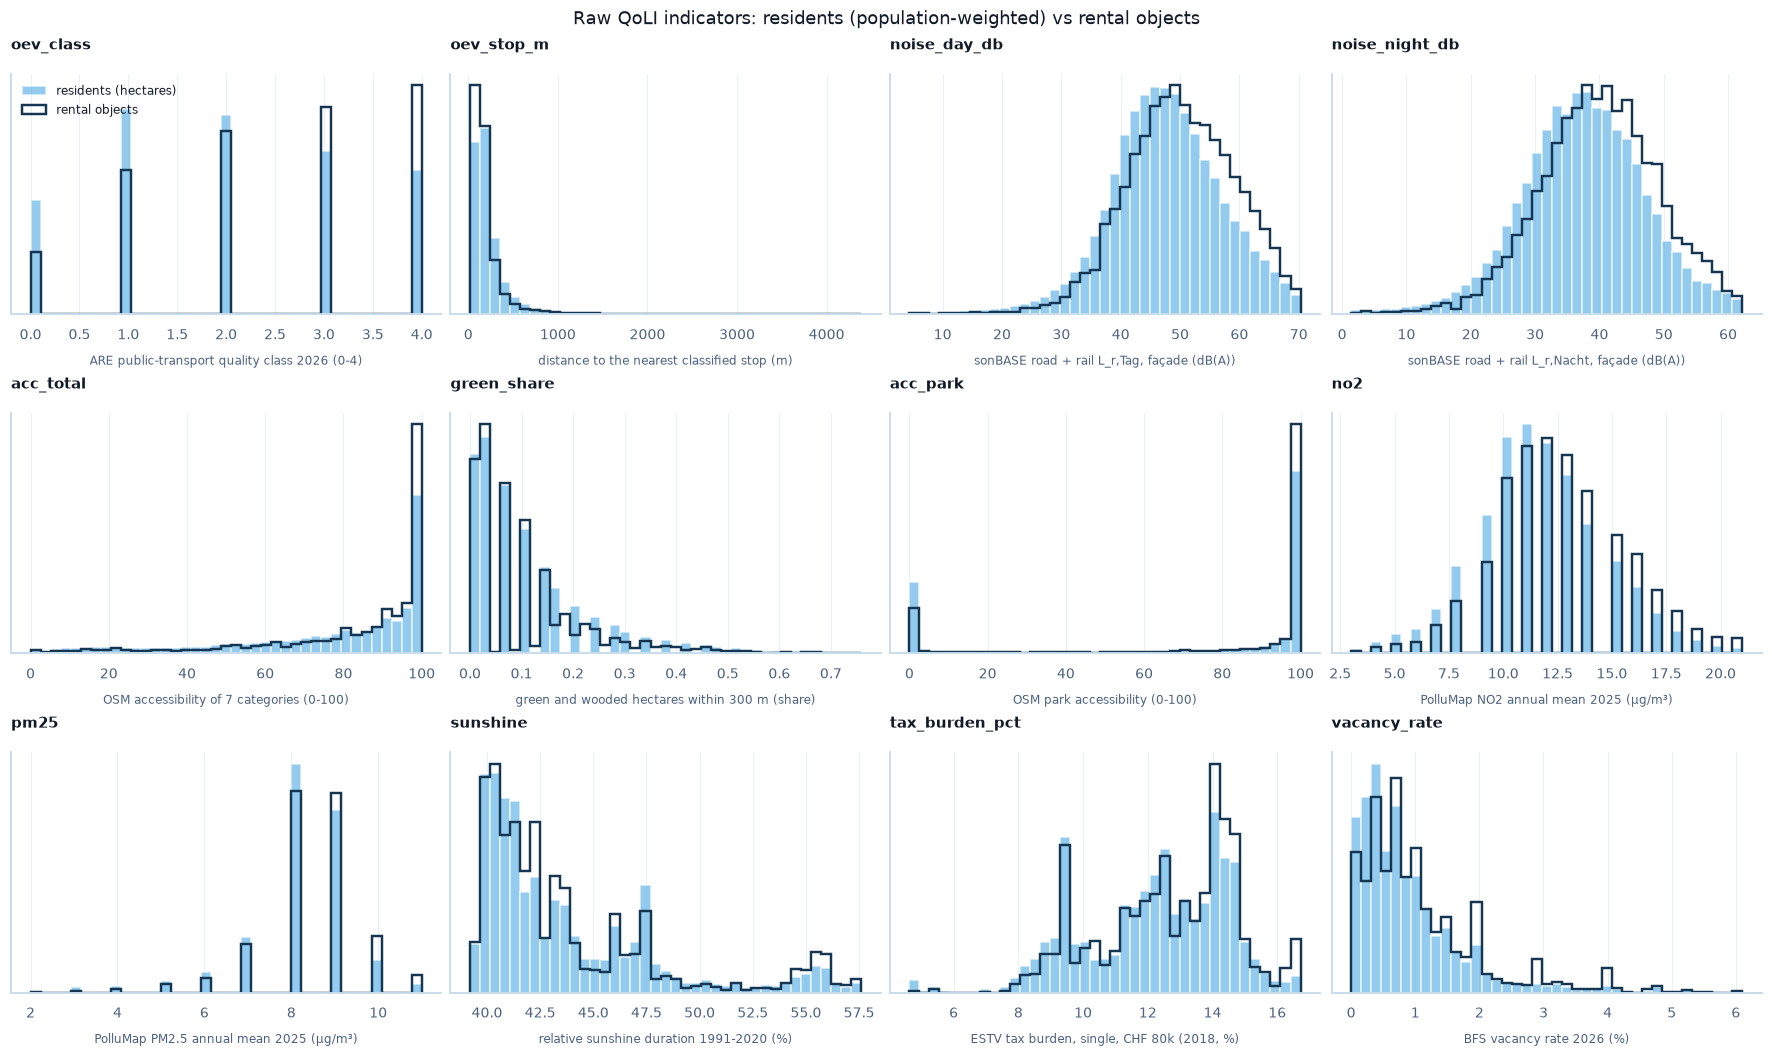

,residents (weighted median),objects (median)
oev_class,2.00,3.00
oev_stop_m,175.33,143.55
noise_day_db,47.60,50.10
noise_night_db,37.60,40.01
acc_total,85.47,92.51
green_share,0.07,0.07
acc_park,97.39,100.00
no2,12.00,12.00
pm25,8.00,9.00
sunshine,42.14,42.14


In [8]:
labels = {i.name: i.description for i in CANDIDATES}
fig, axes = plt.subplots(3, 4, figsize=(16, 9.5), layout="constrained")
pop_w = hect["population"].to_numpy()
for ax, ind in zip(axes.flat, CANDIDATES, strict=False):
    h, o = raw_hect[ind.name].to_numpy(), raw_obj[ind.name].dropna().to_numpy()
    ok = np.isfinite(h)
    lo, hi = np.quantile(np.concatenate([h[ok], o]), [0.005, 0.995])
    bins = np.linspace(lo, hi, 40) if hi > lo else 10
    ax.hist(h[ok], bins=bins, weights=pop_w[ok], density=True, color=COLORS["secondary"],
            alpha=0.7, label="residents (hectares)")
    ax.hist(o, bins=bins, density=True, histtype="step", lw=1.6, color=COLORS["dark"],
            label="rental objects")
    ax.set_title(ind.name, fontsize=10)
    ax.set_yticks([])
    ax.set_xlabel(labels[ind.name], fontsize=8)
for ax in axes.flat[len(CANDIDATES):]:
    ax.axis("off")
axes.flat[0].legend(fontsize=8)
fig.suptitle("Raw QoLI indicators: residents (population-weighted) vs rental objects")
save_fig(fig, "qoli_raw_indicators", paths.figures)
plt.show()

compare = pd.DataFrame({
    "residents (weighted median)": [weighted_quantile(raw_hect[i.name], pop_w, 0.5)
                                    for i in CANDIDATES],
    "objects (median)": [raw_obj[i.name].median() for i in CANDIDATES],
}, index=[i.name for i in CANDIDATES])
display(compare.round(2))

---

## 7. Environmental Thresholds: LSV and WHO

The proposal asks for thresholds *on the metrics actually available*. sonBASE provides the Swiss
rating levels L<sub>r,Tag</sub> (06–22 h) and L<sub>r,Nacht</sub> (22–06 h), so the primary
comparison is with the **impact thresholds of the noise abatement ordinance** (LSV, sensitivity
level II, residential zones: 60 dB(A) day, 50 dB(A) night), **separately for road and rail**
(LSV Annexes 3 and 4; levels of different source types are not summed for the legal
assessment).

The **WHO Environmental Noise Guidelines** (2018) use L<sub>den</sub>: 53 dB for road and 54 dB
for rail traffic. L<sub>den</sub> is only approximated here (`lden_from_lr`): the evening level
is set equal to the day rating level and the Swiss level corrections are ignored. The shares
are therefore descriptive and labelled as approximations.

For air quality the same logic applies to the PolluMap annual means: the Swiss ambient air
limits (LRV: NO₂ 30 µg/m³, PM2.5 10 µg/m³) and the WHO 2021 air quality guidelines (NO₂
10 µg/m³, PM2.5 5 µg/m³).

All values are **modelled exposures at a façade proxy**, intended by BAFU for statistical
statements, not for an individual building. Places without a modelled level are counted as
below every threshold. Resident shares are population-weighted over hectares (one façade proxy
per hectare centre), object shares count apartments.

In [9]:
def threshold_table(raw: pd.DataFrame, weights: np.ndarray | None) -> pd.Series:
    w = np.ones(len(raw)) if weights is None else weights
    share = {}
    for src in ("road", "rail"):
        day = raw[f"{src}_day_db"].fillna(0.0)  # no modelled level nearby: below every limit
        night = raw[f"{src}_night_db"].fillna(0.0)
        lsv = lsv_exceedance(day, night, LSV_THRESHOLDS_DBA)
        for col in ("exceeds_day", "exceeds_night", "exceeds_any"):
            share[f"{src}: LSV {col.split('_')[1]}"] = np.average(lsv[col].astype(bool), weights=w)
        lden = lden_from_lr(day, night)
        share[f"{src}: WHO L_den > {WHO_LDEN_DB[src]:.0f} dB (approx.)"] = np.average(
            lden > WHO_LDEN_DB[src], weights=w)
    for col, limits in (("no2", (30.0, 10.0)), ("pm25", (10.0, 5.0))):
        ok = raw[col].notna().to_numpy()
        share[f"{col}: above LRV {limits[0]:g}"] = np.average(raw[col][ok] > limits[0],
                                                             weights=w[ok])
        share[f"{col}: above WHO 2021 {limits[1]:g}"] = np.average(raw[col][ok] > limits[1],
                                                                  weights=w[ok])
    return pd.Series(share) * 100


thresholds = pd.DataFrame({
    "residents (%)": threshold_table(raw_hect, hect["population"].to_numpy()),
    "rental objects (%)": threshold_table(raw_obj, None),
}).rename_axis("threshold")
(paths.results / "qoli_thresholds.md").write_text(to_markdown(thresholds, floatfmt=".1f") + "\n")
display(thresholds.round(1))

,residents (%),rental objects (%)
threshold,,
road: LSV day,10.0,15.0
road: LSV night,8.7,12.9
road: LSV any,11.0,16.1
road: WHO L_den > 53 dB (approx.),31.8,42.4
rail: LSV day,0.3,0.1
rail: LSV night,0.6,0.4
rail: LSV any,0.6,0.4
rail: WHO L_den > 54 dB (approx.),1.3,1.2
no2: above LRV 30,0.1,0.0


**Interpretation.** The table separates the legal view (LSV, per source) from the health view
(WHO, approximated).

- **Plausibility of the noise layer.** About 11 % of the residents live where the modelled road
  noise exceeds an LSV limit by day or night. BAFU reports about 740,000 people (≈ 8.5 %) above
  the road-noise limits for 2021, counted per building and dwelling. The remaining gap is the
  expected effect of using one point per hectare instead of every dwelling's façade; the
  first estimator (maximum of a 20 m square) gave 25 % and was therefore replaced (section 5).
- **Night is the binding constraint relative to its limit**, road dominates rail (rail limits
  are exceeded for well under 1 % of residents), and the WHO guideline is much stricter than the
  LSV: about a third of the residents are above 53 dB L<sub>den</sub> (approximated).
- **Rental objects are more exposed** than the average resident (16 % above an LSV road limit),
  because listings concentrate in towns along main roads.
- **Air.** Almost nobody lives above the Swiss LRV limits, but most residents are above the
  stricter WHO 2021 guidelines (NO₂: about two thirds, PM2.5: almost everyone). Within
  Switzerland the air indicators therefore discriminate mostly between towns and the countryside.

None of this is a legal assessment of a listing; in the app a flat is described as "modelled
road noise above the LSV night limit", never as "illegal".

---

## 8. Multivariate Analysis: Do the Indicators Fit Their Dimensions?

The handbook asks whether the statistical structure supports the theoretical one (step 4). Three
checks on the normalised indicators of all inhabited hectares:

1. **Correlation matrix** (Spearman): indicators of one dimension should correlate positively,
   indicators of different dimensions should not be redundant (|ρ| ≫ 0.8 would double-count).
2. **Cronbach's α** per dimension: above about 0.7, the indicators measure one construct.
3. **PCA**: if one component explained almost everything, the "index" would be a single
   urbanity axis with extra steps.

Normalisation itself follows in section 9; the checks use the same normalised values.

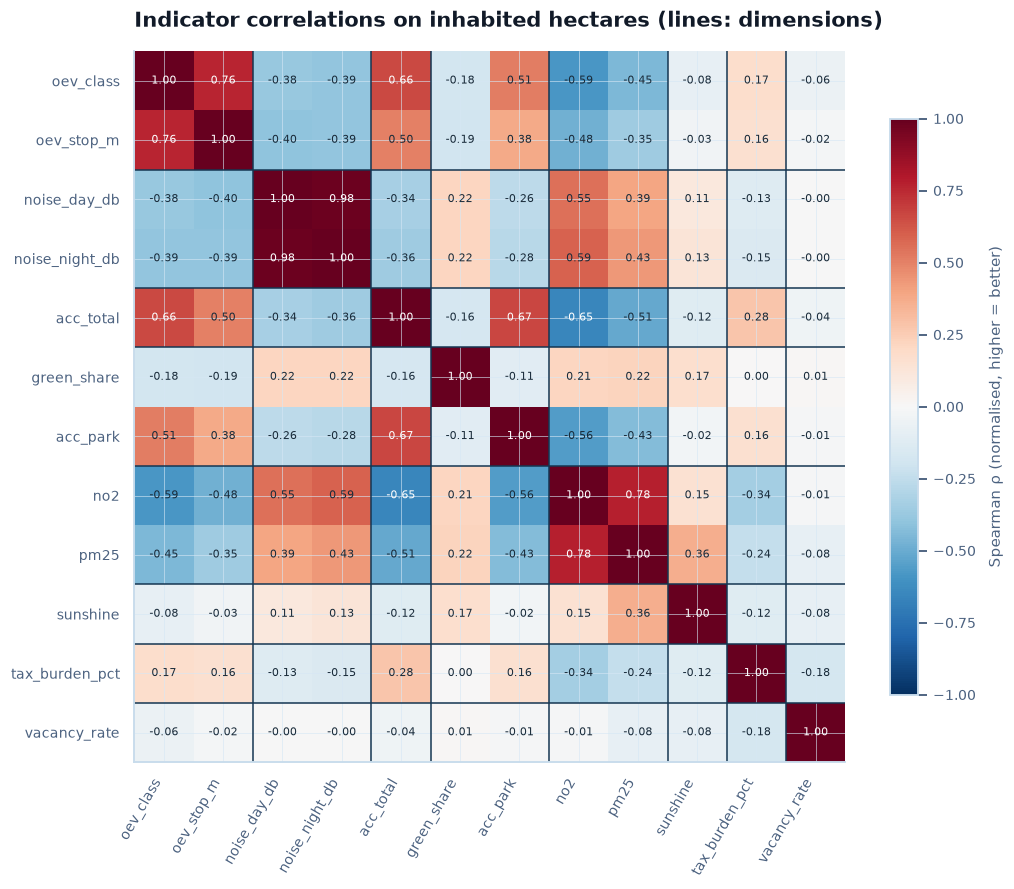

,n_indicators,cronbach_alpha,mean_spearman
dimension,,,
transport,2,0.761,0.760
noise,2,0.991,0.983
amenities,1,NaN,NaN
green,2,-0.248,-0.112
air,2,0.870,0.778
sunshine,1,NaN,NaN
tax,1,NaN,NaN
housing,1,NaN,NaN


green: α = -0.25 < 0.5 -> parks move into the accessibility score (acc_total_all), green = land-use share only


final core indicators: ['oev_class', 'oev_stop_m', 'noise_day_db', 'noise_night_db', 'acc_total_all', 'green_share']


,PC1,PC2,PC3
oev_class,-0.43,0.46,0.05
oev_stop_m,-0.42,0.31,0.05
noise_day_db,0.46,0.50,-0.19
noise_night_db,0.46,0.49,-0.20
acc_total_all,-0.40,0.42,0.01
green_share,0.24,0.16,0.96
explained variance,0.53,0.19,0.14


In [10]:
qoli_bounds = normalization_bounds(raw_hect, ALL_INDICATORS)  # reference: inhabited hectares


def normalise(raw: pd.DataFrame, indicators: list[Indicator], **kw: object) -> pd.DataFrame:
    norm = minmax_normalize(raw, indicators, bounds=qoli_bounds.loc[[i.name for i in indicators]],
                            **kw)
    return apply_quiet_noise(norm, raw)  # no modelled road/rail level within 100 m = quietest


norm_hect = normalise(raw_hect, ALL_INDICATORS)
norm_obj = normalise(raw_obj, ALL_INDICATORS)

corr = norm_hect[[i.name for i in CANDIDATES]].sample(
    min(len(norm_hect), 60_000), random_state=RANDOM_STATE).corr("spearman")
fig, ax = plt.subplots(figsize=(9.5, 8))
im = ax.imshow(corr, cmap="RdBu_r", norm=TwoSlopeNorm(0, -1, 1))
ax.set_xticks(range(len(corr)), corr.columns, rotation=60, ha="right")
ax.set_yticks(range(len(corr)), corr.index)
for (r, c), v in np.ndenumerate(corr.to_numpy()):
    ax.text(c, r, f"{v:.2f}", ha="center", va="center", fontsize=7,
            color="white" if abs(v) > 0.6 else COLORS["neutral"])
dims_of = [i.dimension for i in CANDIDATES]
for k in range(1, len(dims_of)):
    if dims_of[k] != dims_of[k - 1]:
        ax.axhline(k - 0.5, color=COLORS["dark"], lw=1)
        ax.axvline(k - 0.5, color=COLORS["dark"], lw=1)
fig.colorbar(im, ax=ax, shrink=0.8, label="Spearman ρ (normalised, higher = better)")
ax.set_title("Indicator correlations on inhabited hectares (lines: dimensions)")
fig.tight_layout()
save_fig(fig, "qoli_indicator_correlation", paths.figures)
plt.show()

consistency = dimension_consistency(norm_hect, CANDIDATES)
display(consistency.round(3))

ALPHA_MIN = 0.5  # revision rule of section 2
green_alpha = consistency["cronbach_alpha"].get("green", np.nan)
if osm is not None and green_alpha < ALPHA_MIN:
    CORE = [ACC_ALL if i.name == "acc_total" else i for i in CANDIDATE_CORE
            if i.name != "acc_park"]
    print(f"green: α = {green_alpha:.2f} < {ALPHA_MIN} -> parks move into the accessibility "
          "score (acc_total_all), green = land-use share only")
else:
    CORE = CANDIDATE_CORE
    print(f"green: α = {green_alpha:.2f} -> candidate set kept")
EXTENDED = CORE + EXTENSION
DIMS_CORE = list(dict.fromkeys(i.dimension for i in CORE))
DIMS_EXT = list(dict.fromkeys(i.dimension for i in EXTENDED))
consistency = dimension_consistency(norm_hect, EXTENDED)  # final set, exported in section 16
print("final core indicators:", [i.name for i in CORE])

core_cols = [i.name for i in CORE]
pca_input = norm_hect[core_cols].dropna()
pca = PCA().fit((pca_input - pca_input.mean()) / pca_input.std())
pca_table = pd.DataFrame(pca.components_[:3].T, index=core_cols,
                         columns=[f"PC{k + 1}" for k in range(3)])
pca_table.loc["explained variance"] = pca.explained_variance_ratio_[:3]
display(pca_table.round(2))

**Interpretation.** The correlation matrix shows the central tension of every location index:
transport and amenities rise with urbanity, while quietness and green share fall with it, so
these dimensions correlate *negatively*. This is not a flaw but the substance of the index: an
urban apartment buys access with noise, a rural one buys quiet with distance.

The consistency check triggered the pre-stated revision rule once: land-use greenery and OSM
park access correlate *negatively* (α < 0), because parks are an urban feature while forest and
woods surround villages. Averaging them would cancel the dimension out, so parks now count as an
eighth amenity category (as listed in the proposal) and the green dimension is the land-use
share alone. Transport (α ≈ 0.76), noise (α ≈ 0.99, day and night levels are almost the same
information) and air (α ≈ 0.87) are internally consistent.

The first principal component of the final core indicators explains about half of the variance
and loads with opposite signs on access (transport, amenities) and quietness/green: the
dimensions are not redundant, and equal weights across dimensions, rather than PCA weights that
would just reproduce the urbanity axis, are the transparent choice the OECD Better Life Index
also makes.

---

## 9. Normalisation

Winsorised min–max normalisation to 0–100 with 100 = best (handbook step 5, OECD BLI):

- bounds are the 1 % and 99 % quantiles over **all inhabited hectares** (`qoli_bounds`), after a
  `log1p` transform for the skewed stop distance and vacancy rate; values outside are clipped;
- indicators where less is better (noise, distance, air, tax) are flipped;
- the same bounds score the rental objects and any new address in the app, so 100 always means
  "as good as the best 1 % of Swiss inhabited places".

The bounds are exported with the indicator definitions to `models/qoli_spec.json` (section 16).

,lo,hi,transform,better,dimension
oev_class,0.000,4.000,none,higher,transport
oev_stop_m,3.312,8.155,log1p,lower,transport
noise_day_db,8.200,68.582,none,lower,noise
noise_night_db,3.000,60.057,none,lower,noise
acc_total_all,0.530,100.000,none,higher,amenities
green_share,0.000,0.690,none,higher,green
no2,3.000,19.000,none,lower,air
pm25,3.000,11.000,none,lower,air
sunshine,39.354,57.049,none,higher,sunshine
tax_burden_pct,4.950,16.469,none,lower,tax


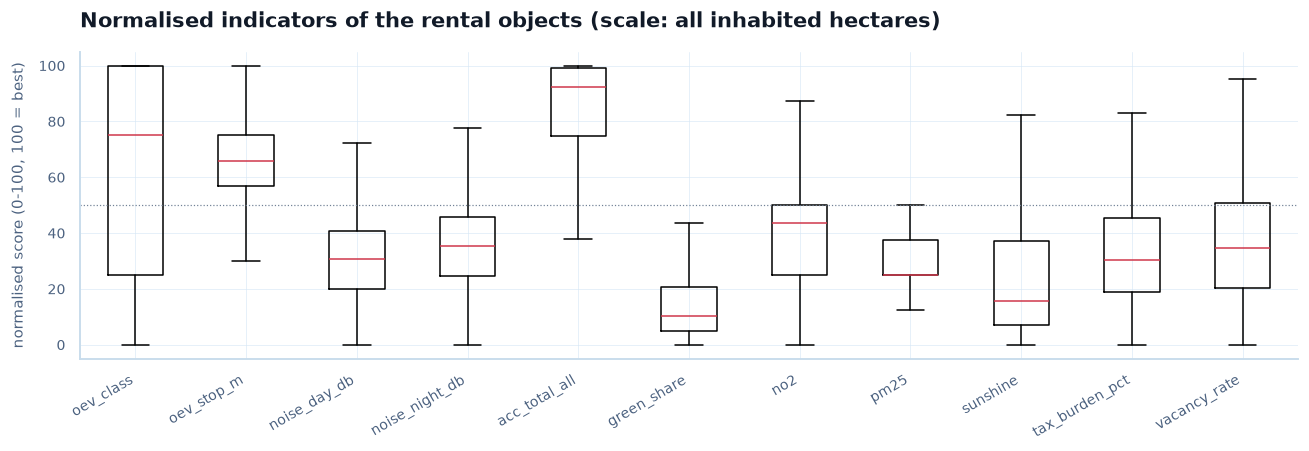

In [11]:
bounds_view = qoli_bounds.loc[[i.name for i in EXTENDED]].assign(
    transform=[i.transform for i in EXTENDED],
    better=["higher" if i.higher_is_better else "lower" for i in EXTENDED],
    dimension=[i.dimension for i in EXTENDED])
display(bounds_view.round(3))

fig, ax = plt.subplots(figsize=(12, 4.2))
data = [norm_obj[i.name].dropna() for i in EXTENDED]
ax.boxplot(data, tick_labels=[i.name for i in EXTENDED], showfliers=False,
           medianprops={"color": COLORS["reference"]})
ax.axhline(50, color=COLORS["gray"], lw=0.8, ls=":")
ax.set_ylabel("normalised score (0-100, 100 = best)")
ax.set_title("Normalised indicators of the rental objects (scale: all inhabited hectares)")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
fig.tight_layout()
save_fig(fig, "qoli_normalised_objects", paths.figures)
plt.show()

---

## 10. Weighting and Aggregation

**Within a dimension:** equal weights (arithmetic mean of the normalised indicators).
**Across dimensions:** user-defined weights, equal by default, linear aggregation; this is the
OECD Better Life Index rule and what the app sliders will set. A unit without a score in a
weighted dimension gets no index.

Scores are computed for hectares and objects. Municipal scores are the **population-weighted
mean over the inhabited hectares** of the municipality, i.e. the quality of life of the average
resident, not of the average square kilometre or of the average listing.

Two example weight profiles show what the sliders do: a *family* profile (green and amenities
count double) and a *commuter* profile (transport counts triple).

In [12]:
qoli_h, dims_h = aggregate(norm_hect, CORE)
qoli_ext_h, dims_ext_h = aggregate(norm_hect, EXTENDED)
qoli_o, dims_o = aggregate(norm_obj, CORE)
qoli_ext_o, dims_ext_o = aggregate(norm_obj, EXTENDED)

pop = hect["population"]
muni_id = hect["municipality_id"].astype("int64")
muni = weighted_unit_scores(
    dims_ext_h.assign(qoli=qoli_h, qoli_ext=qoli_ext_h), pop, muni_id).rename_axis(
    "municipality_id")
muni = muni.join(admin_units.set_index("municipality_id")[
    ["municipality_name", "district_id", "canton", "lang_region", "muni_density"]])
print(f"QoLI (core) for {qoli_o.notna().mean():.1%} of objects, {qoli_h.notna().mean():.1%} of "
      f"hectares; extended: {qoli_ext_o.notna().mean():.1%} / {qoli_ext_h.notna().mean():.1%}; "
      f"{muni['qoli'].notna().sum():,} municipalities with a core score")

PROFILES = {
    "equal": dict.fromkeys(DIMS_CORE, 1.0),
    "family": {"transport": 1.0, "noise": 1.0, "amenities": 2.0, "green": 2.0},
    "commuter": {"transport": 3.0, "noise": 1.0, "amenities": 1.0, "green": 1.0},
}
PROFILES = {k: {d: w.get(d, 1.0) for d in DIMS_CORE} for k, w in PROFILES.items()}
profile_scores = {k: aggregate(norm_hect, CORE, w)[0] for k, w in PROFILES.items()}
muni_profiles = weighted_unit_scores(pd.DataFrame(profile_scores), pop, muni_id)
big = muni[muni["weight"] >= 30_000].index  # municipalities with >= 30,000 residents
display(muni_profiles.loc[big, list(PROFILES)].join(muni["municipality_name"])
        .set_index("municipality_name").sort_values("equal", ascending=False).round(1))

QoLI (core) for 100.0% of objects, 100.0% of hectares; extended: 100.0% / 100.0%; 2,110 municipalities with a core score


,equal,family,commuter
municipality_name,,,
Luzern,58.1,58.6,64.3
Bern,57.4,58.0,63.7
Genève,57.4,57.3,66.3
Lausanne,57.2,57.6,65.1
Basel,57.1,56.6,65.0
Zürich,57.1,57.3,64.4
Fribourg,56.1,55.9,63.3
Vernier,56.0,56.3,64.1
Schaffhausen,55.6,56.1,60.0


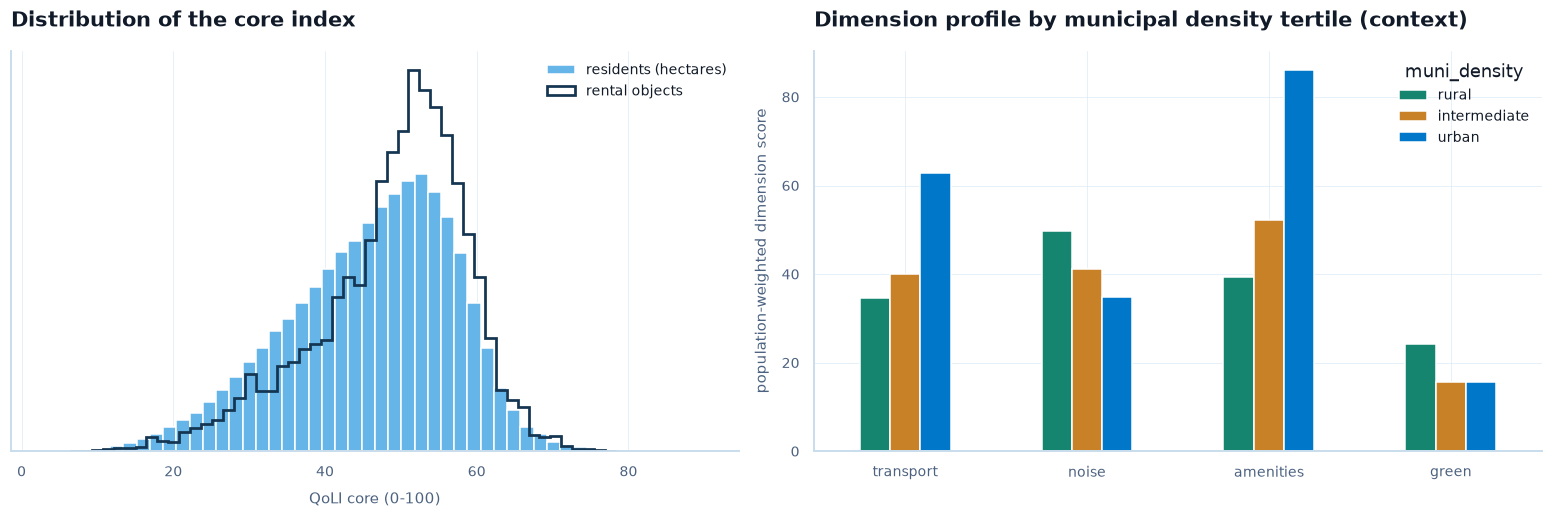

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), layout="constrained")
axes[0].hist(qoli_h, bins=50, weights=pop, density=True, color=COLORS["secondary"],
             label="residents (hectares)")
axes[0].hist(qoli_o, bins=50, density=True, histtype="step", lw=1.8, color=COLORS["dark"],
             label="rental objects")
axes[0].set_xlabel("QoLI core (0-100)")
axes[0].set_yticks([])
axes[0].legend()
axes[0].set_title("Distribution of the core index")
dens = pd.qcut(muni["muni_density"], 3, labels=["rural", "intermediate", "urban"])
profile = weighted_unit_scores(muni[DIMS_CORE], muni["weight"], dens)[DIMS_CORE]
profile.T.plot.bar(ax=axes[1], color=[COLORS["teal"], COLORS["orange"], COLORS["primary"]],
                   rot=0)
axes[1].set_ylabel("population-weighted dimension score")
axes[1].set_title("Dimension profile by municipal density tertile (context)")
save_fig(fig, "qoli_distribution_profile", paths.figures)
plt.show()

**Interpretation.** The density profile makes the trade-off of section 8 visible: urban
municipalities win transport and amenities, rural ones win noise and green, so the equally
weighted index differs much less between town and country than any single dimension. This is the
intended behaviour of a *quality-of-life* index, as opposed to a centrality index. Among the
larger towns, the equal-weight scores lie within a few points of each other (Lucerne, Bern,
Geneva, Lausanne, Basel and Zürich all around 57–58); the commuter profile lifts the large
cities by six to nine points, while the family profile changes little because amenities favour
towns and green favours the countryside. This is why the app exposes the weights instead of
publishing one ranking.

---

## 11. RQ4, Part 1: Uncertainty and Sensitivity of the Ranking

RQ4 asks whether a valid index can be built *without ground truth*. The first criterion is
**robustness**: the ranking must not hinge on arbitrary modelling choices. The evaluation plan
fixes the main test (Dirichlet weight perturbation, 500 draws, median Spearman correlation with
the baseline ranks). The decision rule applied here, stated before looking at the result:

> **Stable** if the median Spearman ρ under weight perturbation is at least 0.90 *and* its 5th
> percentile at least 0.80, on objects and on municipalities.

The rule is a notebook-level criterion (the plan names the statistic, not a threshold) and is
reported as such. Beyond weights, the handbook recommends varying the other choices as well
(step 7). Each alternative below is compared with the baseline by Spearman ρ, mean absolute rank
shift (percentile points) and the share of the top decile that stays in the top decile:

| Choice | Baseline | Alternative |
|---|---|---|
| weights | equal | Dirichlet (concentration 10, mean = equal) |
| normalisation | winsorised min–max | percentile ranks; min–max without winsorising |
| aggregation | linear (full compensation) | weighted geometric mean (limited compensation) |
| indicator set | 4 core dimensions | leave one dimension out; extended index (8 dimensions) |
| green radius | 300 m | 500 m |

In [14]:
t0 = time.time()
muni_dims = muni.loc[muni["qoli"].notna(), DIMS_CORE]
sens = {}
for unit, dims, base_w in (("objects", dims_o[qoli_o.notna()], PROFILES["equal"]),
                           ("municipalities", muni_dims, PROFILES["equal"])):
    draws = weight_sensitivity(dims, n_draws=BUDGET["sensitivity_draws"], seed=RANDOM_STATE,
                               base_weights=base_w)
    sens[unit] = {"units": len(dims), "spearman_median": draws["spearman"].median(),
                  "spearman_p05": draws["spearman"].quantile(0.05),
                  "top_decile_retention": draws["top_decile_retention"].mean(),
                  "mean_abs_rank_shift_pct": draws["mean_abs_rank_shift_pct"].mean()}
weight_sens = pd.DataFrame(sens).T
weight_sens["stable"] = (weight_sens["spearman_median"] >= 0.90) & (
    weight_sens["spearman_p05"] >= 0.80)
print(f"{BUDGET['sensitivity_draws']} Dirichlet draws in {time.time() - t0:.1f}s")
display(weight_sens.round(3))


def to_muni(score: pd.Series) -> pd.Series:
    return weighted_unit_scores(score.rename("s").to_frame(), pop, muni_id)["s"]


pct_h = apply_quiet_noise(percentile_normalize(raw_hect, CORE), raw_hect)
pct_o = apply_quiet_noise(percentile_normalize(raw_obj, CORE, reference=raw_hect), raw_obj)
raw_mm_bounds = normalization_bounds(raw_hect, CORE, winsor=None)
mm_h = apply_quiet_noise(minmax_normalize(raw_hect, CORE, bounds=raw_mm_bounds), raw_hect)
mm_o = apply_quiet_noise(minmax_normalize(raw_obj, CORE, bounds=raw_mm_bounds), raw_obj)

# Green share within 500 m instead of 300 m, normalised on the hectares as well.
green_ind = next(i for i in CORE if i.name == "green_share")
g500_h = pd.DataFrame({"green_share": green_share(hect[["east", "north"]].to_numpy(float),
                                                  layers.landuse, radius_m=500.0)},
                      index=hect.index)
g500_o = pd.DataFrame({"green_share": green_share(objects[["east", "north"]].to_numpy(float),
                                                  layers.landuse, radius_m=500.0)},
                      index=objects.index)
g500_bounds = normalization_bounds(g500_h, [green_ind])
g500_norm_h = norm_hect.assign(green_share=minmax_normalize(g500_h, [green_ind],
                                                            bounds=g500_bounds)["green_share"])
g500_norm_o = norm_obj.assign(green_share=minmax_normalize(g500_o, [green_ind],
                                                           bounds=g500_bounds)["green_share"])

alt_obj = {
    "percentile normalisation": aggregate(pct_o, CORE)[0],
    "min-max without winsorising": aggregate(mm_o, CORE)[0],
    "geometric aggregation": geometric_aggregate(dims_o),
    **leave_one_out(dims_o),
    "extended index (8 dimensions)": qoli_ext_o,
    "green radius 500 m": aggregate(g500_norm_o, CORE)[0],
}
alt_muni = {
    "percentile normalisation": to_muni(aggregate(pct_h, CORE)[0]),
    "min-max without winsorising": to_muni(aggregate(mm_h, CORE)[0]),
    "geometric aggregation": to_muni(geometric_aggregate(dims_h)),
    **{k: to_muni(v) for k, v in leave_one_out(dims_h).items()},
    "extended index (8 dimensions)": muni["qoli_ext"],
    "green radius 500 m": to_muni(aggregate(g500_norm_h, CORE)[0]),
}
robust = pd.concat({"objects": rank_comparison(qoli_o, alt_obj),
                    "municipalities": rank_comparison(muni["qoli"], alt_muni)},
                   names=["unit"])
conc_rows = {}
for conc in (5.0, 10.0, 20.0, 50.0):  # descriptive: the decision above uses concentration 10
    d = weight_sensitivity(muni_dims, n_draws=BUDGET["sensitivity_draws"], seed=RANDOM_STATE,
                           concentration=conc)
    conc_rows[conc] = {"weight sd (equal 0.25)": float(d.filter(like="w_").std().mean()),
                       "spearman_median": d["spearman"].median(),
                       "spearman_p05": d["spearman"].quantile(0.05)}
display(pd.DataFrame(conc_rows).T.rename_axis("Dirichlet concentration (municipalities)")
        .round(3))
(paths.results / "qoli_weight_sensitivity.md").write_text(
    f"<!-- {BUDGET['sensitivity_draws']} Dirichlet draws, session {SESSION_ID} -->\n"
    + to_markdown(weight_sens.rename_axis("unit"), floatfmt=".3f") + "\n")
(paths.results / "qoli_specification_robustness.md").write_text(
    to_markdown(robust.reset_index(), floatfmt=".3f", index=False) + "\n")
display(robust.round(3))

500 Dirichlet draws in 2.6s


,units,spearman_median,spearman_p05,top_decile_retention,mean_abs_rank_shift_pct,stable
objects,8125.0,0.926,0.743,0.701,8.340,False
municipalities,2110.0,0.949,0.719,0.736,7.714,False


,weight sd (equal 0.25),spearman_median,spearman_p05
Dirichlet concentration (municipalities),,,
5.0,0.178,0.913,0.396
10.0,0.129,0.949,0.719
20.0,0.093,0.972,0.845
50.0,0.061,0.988,0.940


n  spearman  \
unit           specification                                   
objects        percentile normalisation       8125     0.915   
               min-max without winsorising    8125     0.982   
               geometric aggregation          8125     0.729   
               without transport              8125     0.831   
               without noise                  8125     0.883   
               without amenities              8125     0.859   
               without green                  8125     0.887   
               extended index (8 dimensions)  8123     0.619   
               green radius 500 m             8125     0.961   
municipalities percentile normalisation       2110     0.969   
               min-max without winsorising    2110     0.989   
               geometric aggregation          2110     0.901   
               without transport              2110     0.928   
               without noise                  2110     0.964   
               without amenities              2110     0.648   
               without green                  2110     0.921   
               extended index (8 dimensions)  2110     0.744   
               green radius 500 m             2110     0.991   

                                              mean_abs_rank_shift_pct  \
unit           specification                                            
objects        percentile normalisation                         8.923   
               min-max without winsorising                      3.722   
               geometric aggregation                           16.359   
               without transport                               12.380   
               without noise                                   10.224   
               without amenities                               10.559   
               without green                                    9.624   
               extended index (8 dimensions)                   19.479   
               green radius 500 m                               5.631   
municipalities percentile normalisation                         5.514   
               min-max without winsorising                      3.127   
               geometric aggregation                            9.686   
               without transport                                8.077   
               without noise                                    5.535   
               without amenities                               19.369   
               without green                                    7.989   
               extended index (8 dimensions)                   16.149   
               green radius 500 m                               2.851   

                                              p90_abs_rank_shift_pct  \
unit           specification                                           
objects        percentile normalisation                       20.519   
               min-max without winsorising                     8.432   
               geometric aggregation                          36.595   
               without transport                              27.932   
               without noise                                  24.220   
               without amenities                              18.767   
               without green                                  19.178   
               extended index (8 dimensions)                  41.923   
               green radius 500 m                             13.400   
municipalities percentile normalisation                       12.186   
               min-max without winsorising                     6.923   
               geometric aggregation                          20.816   
               without transport                              17.074   
               without noise                                  12.613   
               without amenities                              41.821   
               without green                                  15.889   
           

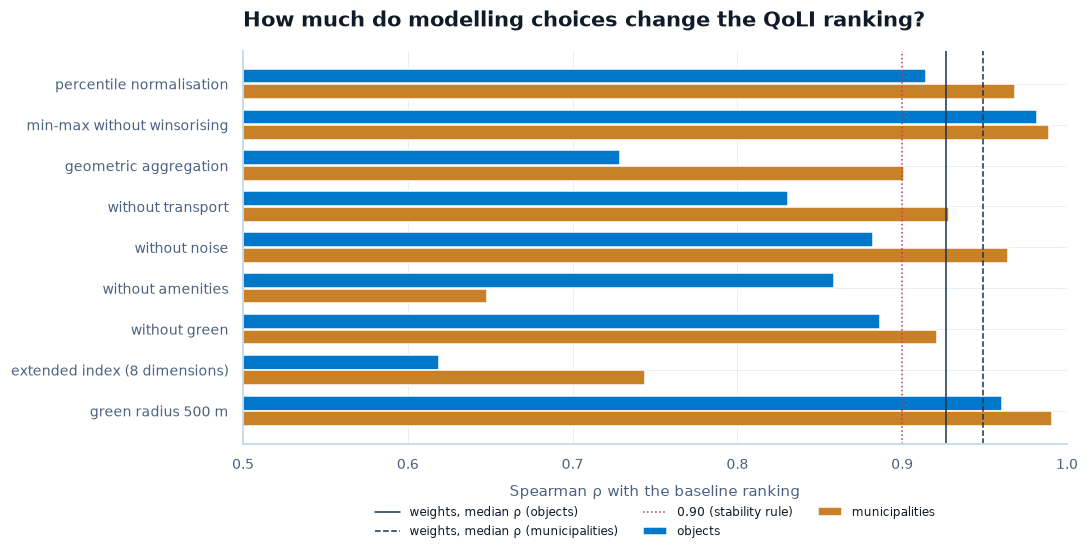

In [15]:
fig, ax = plt.subplots(figsize=(10, 5.2))
plot_df = robust.reset_index()
ypos = np.arange(plot_df["specification"].nunique())
specs = list(dict.fromkeys(plot_df["specification"]))
for k, (unit, color) in enumerate((("objects", COLORS["primary"]),
                                   ("municipalities", COLORS["orange"]))):
    part = plot_df[plot_df["unit"].eq(unit)].set_index("specification").reindex(specs)
    ax.barh(ypos + (k - 0.5) * 0.38, part["spearman"], height=0.36, color=color, label=unit)
for unit, ls in (("objects", "-"), ("municipalities", "--")):
    ax.axvline(weight_sens.loc[unit, "spearman_median"], color=COLORS["dark"], ls=ls, lw=1,
               label=f"weights, median ρ ({unit})")
ax.axvline(0.9, color=COLORS["reference"], lw=1, ls=":", label="0.90 (stability rule)")
ax.set_yticks(ypos, specs)
ax.invert_yaxis()
ax.set_xlim(min(0.5, plot_df["spearman"].min() - 0.05), 1.0)
ax.set_xlabel("Spearman ρ with the baseline ranking")
ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=3)
ax.set_title("How much do modelling choices change the QoLI ranking?")
fig.tight_layout()
save_fig(fig, "qoli_robustness", paths.figures)
plt.show()

**Interpretation.** The weight perturbation answers the pre-registered part of RQ4, and the
answer is **mixed**: the median Spearman correlation stays above 0.9 for objects and
municipalities, but the 5th percentile falls to about 0.72–0.74, so the stated stability rule is
**not** met. The reason is structural, not noise: two dimensions point towards urbanity
(transport, amenities) and two away from it (noise, green). Shifting weight between the two
groups reorders the middle of the ranking. The concentration table shows how quickly this
happens: with weight perturbations half as large (concentration 20–50) the 5th percentile rises
above 0.8; with large perturbations it falls further. The rule is reported as failed, not
re-tuned.

The specification table shows which choices matter more than the weights. Normalisation variants
change little (ρ ≥ 0.9), as does the green radius. The leave-one-dimension-out rows show what
carries the ranking: dropping amenities changes the municipal ranking most (ρ ≈ 0.65), because
amenities is the dimension that separates places with a centre from mere residential areas.
The geometric mean (limited compensation) reorders objects considerably (ρ ≈ 0.73), because many
apartments have one very weak dimension (usually noise in town or transport in the country). The
extended index differs most (ρ ≈ 0.6–0.75), mainly through tax and vacancy, which vary between
municipalities rather than locations.

**Consequence for the app.** A single "official" QoLI ranking would hide value judgements. The
app therefore shows the four dimension scores next to the index and lets users set the weights;
the equally weighted score is a default, not a verdict.

---

## 12. RQ4, Part 2: Convergent Validity Without Ground Truth

There is no measured "quality of life" per address. Validity is therefore assessed by
**convergence with independent indicators** that should relate to location quality, with the
expected sign stated in advance. "Independent" means that the indicator is not an input of the
index and comes from another source:

| Criterion (municipal unless stated) | Source | Expected sign | Reasoning |
|---|---|---|---|
| vacancy rate 2026 | BFS | negative | attractive places are in demand, so fewer flats stand empty |
| population growth 2011–2021 | BFS STATPOP (hectares) | positive | people move to good places ("voting with feet") |
| median asking rent per m² (≥ 5 objects) | our listings | positive | quality of life is capitalised into rents (hedonic theory) |
| BFS distance to services (hectares) | BFS accessibility 2021 | negative (vs amenities score) | indicator-level check of the OSM accessibility against official data |

The core index is tested (the extended index contains vacancy). The family of the three municipal
tests and the indicator check is Holm-corrected at α = 0.05; a criterion **supports validity** if
ρ has the expected sign and the corrected test rejects ρ = 0.

Because all three municipal criteria are also related to urbanity, each correlation is repeated
**within density tertiles**. If the sign survives inside rural, intermediate and urban
municipalities, the index captures more than "how urban is it".

**BFS City Statistics** cover only ten core cities (Zürich, Geneva, Basel, Bern, Lausanne,
Winterthur, Lucerne, St. Gallen, Lugano, Biel/Bienne); with n = 10 they are shown descriptively.
The **BILANZ/IAZI municipal ranking** named in the proposal is not openly available; access could
not be obtained, so this criterion remains open.

In [16]:
hect_2011 = load_hectares(files["hectares"], year=2011)
hect_2011 = geo.assign_admin_units(hect_2011, admin_units, exclude=foreign_mask)
hect_2011 = hect_2011[hect_2011["admin_match"].ne("none")]
pop_2011 = hect_2011.groupby(hect_2011["municipality_id"].astype("int64"))["population"].sum()
pop_2021 = pop.groupby(muni_id).sum()
base_2011 = pop_2011.reindex(pop_2021.index)
growth = ((pop_2021 / base_2011 - 1) * 100).where(base_2011 >= 200)  # small bases are noisy

ppsqm = objects["price"] / objects["area"]
obj_muni = objects["municipality_id"].astype("int64")
rent_m2 = ppsqm.groupby(obj_muni).median().where(obj_muni.value_counts() >= 5).dropna()

criteria = {
    "vacancy rate 2026": (vacancy, -1),
    "population growth 2011-2021": (growth.dropna(), +1),
    "median asking rent CHF/m² (>= 5 objects)": (rent_m2, +1),
}
logging.getLogger("rentml.qoli").setLevel(logging.ERROR)  # partial matches are intended
score = muni["qoli"].dropna()
rows = {}
for name, (ext, sign) in criteria.items():
    ext = ext.rename_axis("municipality_id")
    rows[name] = convergent_validity(score, ext) | {"expected": sign}
    for tert, ids in score.groupby(dens.reindex(score.index), observed=True).groups.items():
        res = convergent_validity(score.loc[ids], ext)
        rows[name][f"rho_{tert}"] = res["rho"]
        rows[name][f"n_{tert}"] = res["n"]

svc_cols = ["d_grocery", "d_pharma", "d_school_o", "d_resto"]
svc = np.log1p(hect[svc_cols]).mean(axis=1).rename_axis("reli")  # mean log distance (BFS)
acc_name = next((i.name for i in CORE if i.dimension == "amenities"), None)
acc = raw_hect[acc_name].rename_axis("reli") if acc_name else None
if acc is not None:
    rows["OSM accessibility vs BFS service distance (hectares)"] = convergent_validity(
        acc, svc) | {"expected": -1}
validity = pd.DataFrame(rows).T
validity["n"] = validity["n"].astype(int)
for col in ("n_rural", "n_intermediate", "n_urban"):
    validity[col] = validity[col].astype("Int64")
validity["sign_ok"] = np.sign(validity["rho"]) == validity["expected"]
holm = holm_correction(validity["p_value"].to_dict())
validity["p_holm"] = holm["p_holm"]
validity["supports_validity"] = validity["sign_ok"] & holm["reject"]
cols = ["n", "expected", "rho", "ci_low", "ci_high", "p_holm", "supports_validity",
        "rho_rural", "n_rural", "rho_intermediate", "n_intermediate", "rho_urban", "n_urban"]
validity = validity[[c for c in cols if c in validity.columns]]
(paths.results / "qoli_convergent_validity.md").write_text(
    to_markdown(validity.rename_axis("criterion"), floatfmt=".3f") + "\n")
display(validity.style.format(precision=3, na_rep="–"))

,n,expected,rho,ci_low,ci_high,p_holm,supports_validity,rho_rural,n_rural,rho_intermediate,n_intermediate,rho_urban,n_urban
vacancy rate 2026,2110,-1.000,-0.014,-0.057,0.029,0.523,False,-0.035,703,0.021,703,-0.097,704
population growth 2011-2021,2026,1.000,-0.055,-0.099,-0.012,0.026,False,-0.186,628,-0.177,694,-0.228,704
median asking rent CHF/m² (>= 5 objects),351,1.000,0.368,0.270,0.458,0.000,True,0.818,18,-0.061,65,0.270,268
OSM accessibility vs BFS service distance (hectares),346701,-1.000,-0.736,-0.738,-0.734,0.000,True,–,–,–,–,–,–


In [17]:
CITY_VARS = {"EC3063I": "social assistance rate (%)",
             "EC1020I_seco": "unemployment rate SECO (%)",
             "SA1025I": "vacancy rate (%)",
             "SA1022V": "living space per person (m²)",
             "EN2052I": "residents above noise limit, day (%)",
             "EN5027I_CH": "wooded and recreational area (%)"}
city_table = fetch_sdmx_csv("CH1.CITYSTAT,DF_CITYSTAT_1,1.0.1", QOLI_DIR / "bfs_citystat.csv",
                            params={"startPeriod": "2018"})
cities = city_statistics(city_table, list(CITY_VARS))
cities = muni[["municipality_name", "qoli"] + DIMS_CORE].join(cities, how="inner")
city_rho = pd.Series({CITY_VARS[v]: cities["qoli"].corr(cities[v], method="spearman")
                      for v in CITY_VARS if cities[v].notna().sum() >= 5}, name="Spearman ρ")
display(cities.set_index("municipality_name")[["qoli", *CITY_VARS]].round(1)
        .sort_values("qoli", ascending=False).rename(columns=CITY_VARS))
display(city_rho.round(2).to_frame().assign(n=len(cities)))

,qoli,social assistance rate (%),unemployment rate SECO (%),vacancy rate (%),living space per person (m²),"residents above noise limit, day (%)",wooded and recreational area (%)
municipality_name,,,,,,,
Luzern,58.1,3.9,2.7,1.0,45.2,11.4,28.4
Bern,57.4,5.0,2.3,0.4,40.2,7.5,NaN
Genève,57.4,7.1,5.1,0.4,36.7,11.8,19.0
Lausanne,57.2,7.2,5.8,0.6,37.1,16.8,46.2
Basel,57.1,5.0,4.4,0.9,40.3,6.5,12.5
Zürich,57.1,3.5,2.9,0.1,39.4,13.5,NaN
St. Gallen,55.5,3.8,2.6,2.3,44.6,9.0,NaN
Biel/Bienne,55.2,9.1,5.6,1.4,41.4,9.5,NaN
Lugano,54.2,3.6,2.6,2.1,48.1,18.3,NaN


,Spearman ρ,n
social assistance rate (%),0.08,10
unemployment rate SECO (%),0.01,10
vacancy rate (%),-0.15,10
living space per person (m²),-0.39,10
"residents above noise limit, day (%)",-0.32,10


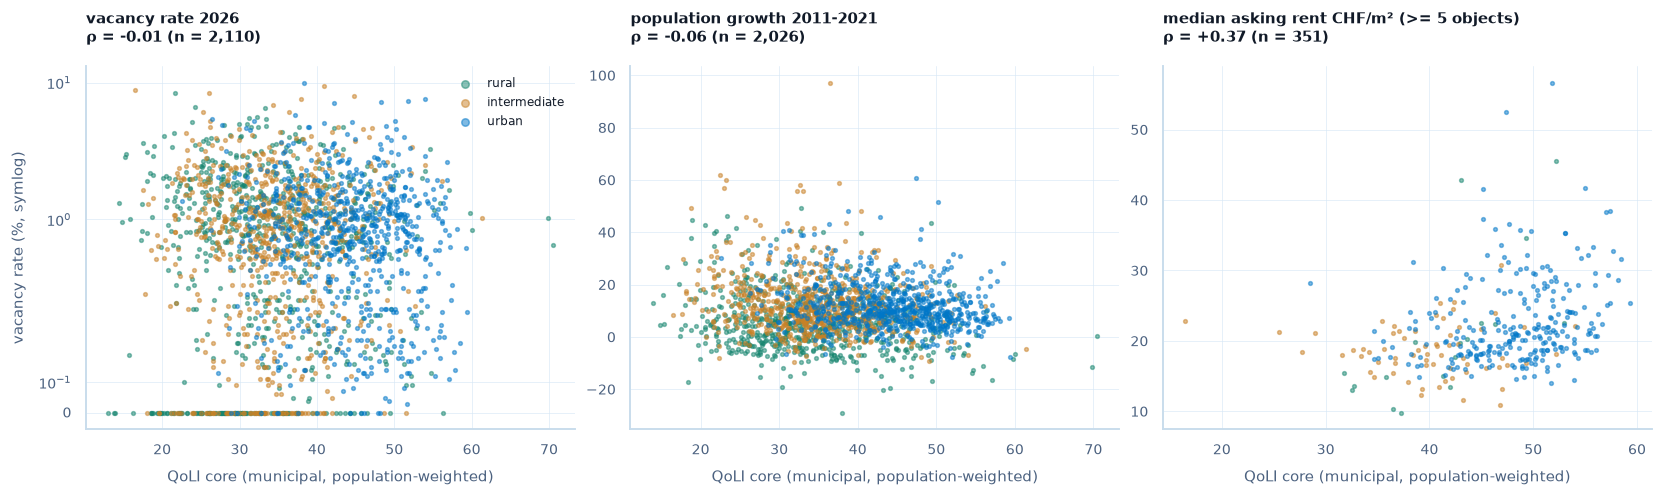

In [18]:
fig, axes = plt.subplots(1, len(criteria), figsize=(15, 4.4), layout="constrained")
for ax, (name, (ext, _)) in zip(axes, criteria.items(), strict=True):
    pair = pd.concat({"q": score, "x": ext.rename_axis("municipality_id")}, axis=1).dropna()
    tert = dens.reindex(pair.index)
    for lab, color in (("rural", COLORS["teal"]), ("intermediate", COLORS["orange"]),
                       ("urban", COLORS["primary"])):
        m = tert.eq(lab).to_numpy()
        ax.scatter(pair["q"][m], pair["x"][m], s=6, alpha=0.5, color=color, label=lab)
    ax.set_xlabel("QoLI core (municipal, population-weighted)")
    ax.set_title(f"{name}\nρ = {validity.loc[name, 'rho']:+.2f} (n = {len(pair):,})", fontsize=10)
    if name.startswith("vacancy"):
        ax.set_yscale("symlog", linthresh=0.5)
        ax.set_ylabel("vacancy rate (%, symlog)")
axes[0].legend(fontsize=8, markerscale=2)
save_fig(fig, "qoli_convergent_validity", paths.figures)
plt.show()

**Interpretation.** Two of the four criteria support validity, one is null and one contradicts
the expectation:

- **Rents capitalise the QoLI** (ρ ≈ +0.37, CI clearly above 0, n = 351 municipalities): places
  with a better location score command higher asking rents per m², as hedonic theory predicts.
  The within-tertile correlations are less clear: strong in the few rural municipalities with
  enough listings (n = 18), positive among urban ones, and about zero in the intermediate
  tertile. Part of the overall effect is therefore urbanity.
- **OSM accessibility agrees with the official BFS distances to services** (ρ ≈ −0.74 over all
  inhabited hectares). The volunteered OSM data are a valid basis for the amenities dimension.
- **Vacancy is unrelated** to the QoLI (ρ ≈ 0, also within tertiles). Vacancy is driven by
  recent construction and regional demand rather than by the local living environment.
- **Population growth 2011–2021 is slightly *negatively* related** to the QoLI, and more clearly
  so within each density tertile (ρ ≈ −0.2). Swiss growth in this decade happened where land
  was zoned and built, in agglomeration belts with weaker transport and amenities, not in the
  best-served places, which were already built up. "Voting with feet" measures housing supply
  more than location quality, so this criterion was a poor choice in hindsight; it is reported,
  not dropped.

The ten City Statistics cities are too few for inference. Their table is a plausibility check:
cities with a larger share of residents above the noise limit tend to score lower (ρ ≈ −0.3,
n = 10). BILANZ/IAZI remains open.

---

## 13. Back to the Details: What Drives a Score?

A composite indicator is only useful if it can be decomposed (handbook step 8). The chart shows
the dimension profile of the five largest cities next to the index, which is what the app will
show as "location explanation" for an address.

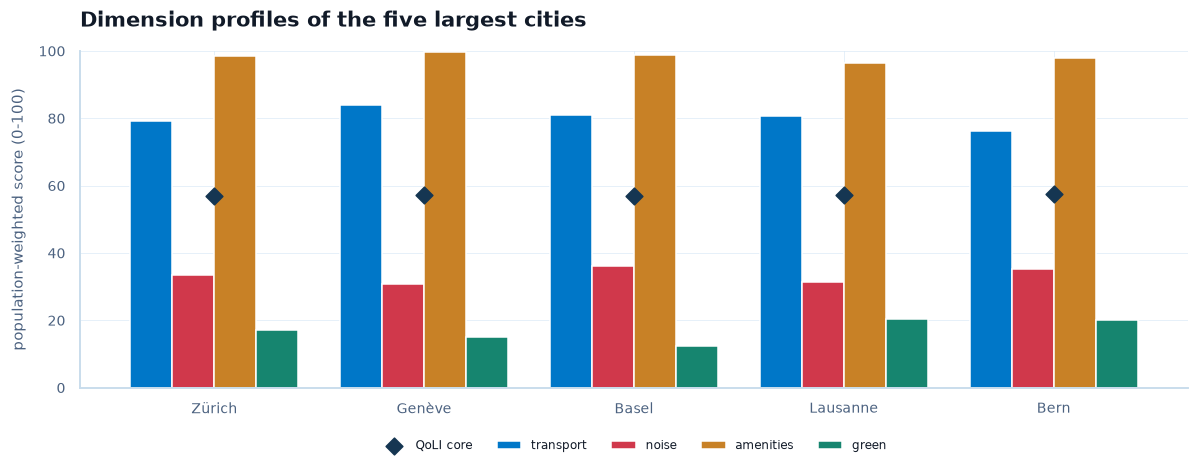

In [19]:
largest = muni.sort_values("weight", ascending=False).head(5)
fig, ax = plt.subplots(figsize=(11, 4.4))
width = 0.8 / len(DIMS_CORE)
palette = [COLORS["primary"], COLORS["reference"], COLORS["orange"], COLORS["teal"]]
for k, (dim, color) in enumerate(zip(DIMS_CORE, palette, strict=False)):
    ax.bar(np.arange(len(largest)) + (k - (len(DIMS_CORE) - 1) / 2) * width, largest[dim],
           width=width, color=color, label=dim)
ax.scatter(np.arange(len(largest)), largest["qoli"], marker="D", s=60, color=COLORS["dark"],
           zorder=3, label="QoLI core")
ax.set_xticks(np.arange(len(largest)), largest["municipality_name"])
ax.set_ylabel("population-weighted score (0-100)")
ax.set_ylim(0, 100)
ax.legend(ncol=5, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.12))
ax.set_title("Dimension profiles of the five largest cities")
fig.tight_layout()
save_fig(fig, "qoli_city_profiles", paths.figures)
plt.show()

---

## 14. Value Score: Quality of Life Relative to Price

The value score (secondary objective) combines the QoLI percentile with the inverted CHF/m²
percentile, equally weighted, **within peer groups** of the same language region and size band
(< 60 m², 60–100 m², > 100 m²), so a small flat in Geneva is compared with small flats in
Romandy, not with houses in the Jura (`rentml.qoli.value_score`).

It is descriptive. Because quality of life is partly priced in, QoLI and CHF/m² correlate
positively; a high value score can also flag unobserved negatives (condition, floor, view) that
neither the index nor the price per m² captures. In the app it is a pointer for further
inspection, never a verdict.

In [20]:
size_band = pd.cut(objects["area"], [0, 60, 100, np.inf], labels=["<60", "60-100", ">100"])
peers = objects["lang_region"].astype(str) + " / " + size_band.astype(str)
value = pd.concat([value_score(qoli_o.loc[idx], ppsqm.loc[idx])
                   for idx in objects.groupby(peers).groups.values()]).reindex(objects.index)
rho_price = qoli_o.corr(ppsqm, method="spearman")
print(f"Spearman(QoLI, CHF/m²) over {int(qoli_o.notna().sum()):,} objects: {rho_price:+.2f}; "
      f"value score for {value.notna().mean():.1%} of the objects")

n_obj = obj_muni.value_counts()
muni_value = pd.DataFrame({
    "objects": n_obj, "median_value": value.groupby(obj_muni).median(),
    "median_chf_m2": ppsqm.groupby(obj_muni).median()}).join(
    muni[["municipality_name", "qoli"]])
value_published = muni_value[muni_value["objects"] >= MIN_MAP_CELL].sort_values("median_value")
print(f"{len(value_published)} municipalities with >= {MIN_MAP_CELL} objects are published")
display(pd.concat([value_published.head(5), value_published.tail(5)]).round(1))

Spearman(QoLI, CHF/m²) over 8,125 objects: +0.28; value score for 100.0% of the objects
78 municipalities with >= 20 objects are published


,objects,median_value,median_chf_m2,municipality_name,qoli
municipality_id,,,,,
4891,22,28.2,21.1,Berg (TG),29.0
293,29,28.3,27.0,Wädenswil,47.7
191,40,35.4,27.9,Dübendorf,51.3
5724,22,36.7,33.2,Nyon,54.2
198,24,39.9,25.3,Uster,49.1
6711,57,70.0,16.4,Delémont,51.3
329,25,71.2,18.8,Langenthal,50.2
371,107,71.4,18.7,Biel/Bienne,55.2
6800,22,72.6,14.9,Porrentruy,49.1


**Interpretation.** QoLI and CHF/m² correlate at about +0.28 over the objects: part of the
location quality is priced in, but most of the rent variation is not explained by it. Among the
78 municipalities that pass the publication rule, the highest median value scores are in the
Jura arc and in mid-sized towns (La Chaux-de-Fonds, Porrentruy, Biel/Bienne, Langenthal,
Delémont), where rents are low relative to a location score in the national middle; the lowest
are in expensive places around Lake Zurich and Lake Geneva (Wädenswil, Dübendorf, Uster, Nyon).
This is a statement about asking rents relative to the location, not about which flats are
worth renting.

---

## 15. Maps: Hectares, Municipalities and Value Score

The QoLI is computed from public geodata only, so it can be shown **for every municipality and
hectare** without revealing any listing. The value score uses asking rents and follows the
publication rule of the app: a municipality is coloured only with at least
`MIN_MAP_CELL` = 20 objects. All maps are drawn in LV95.

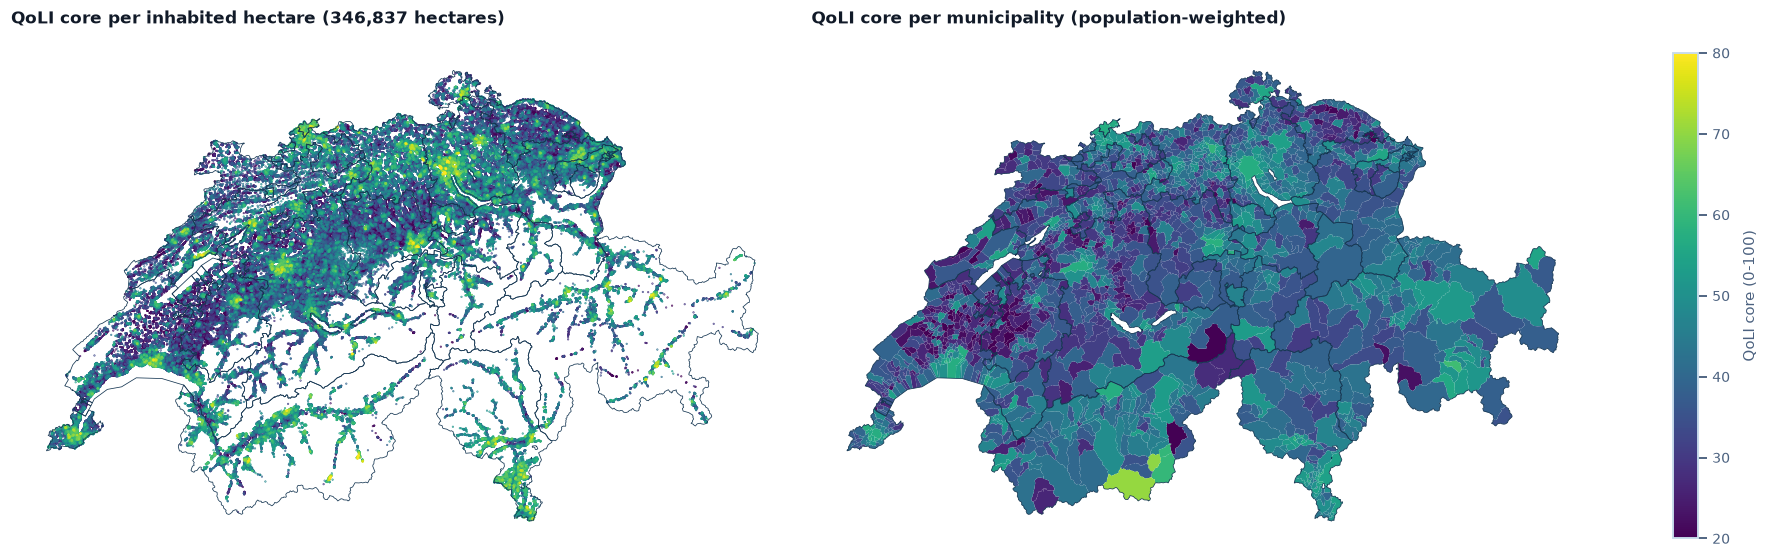

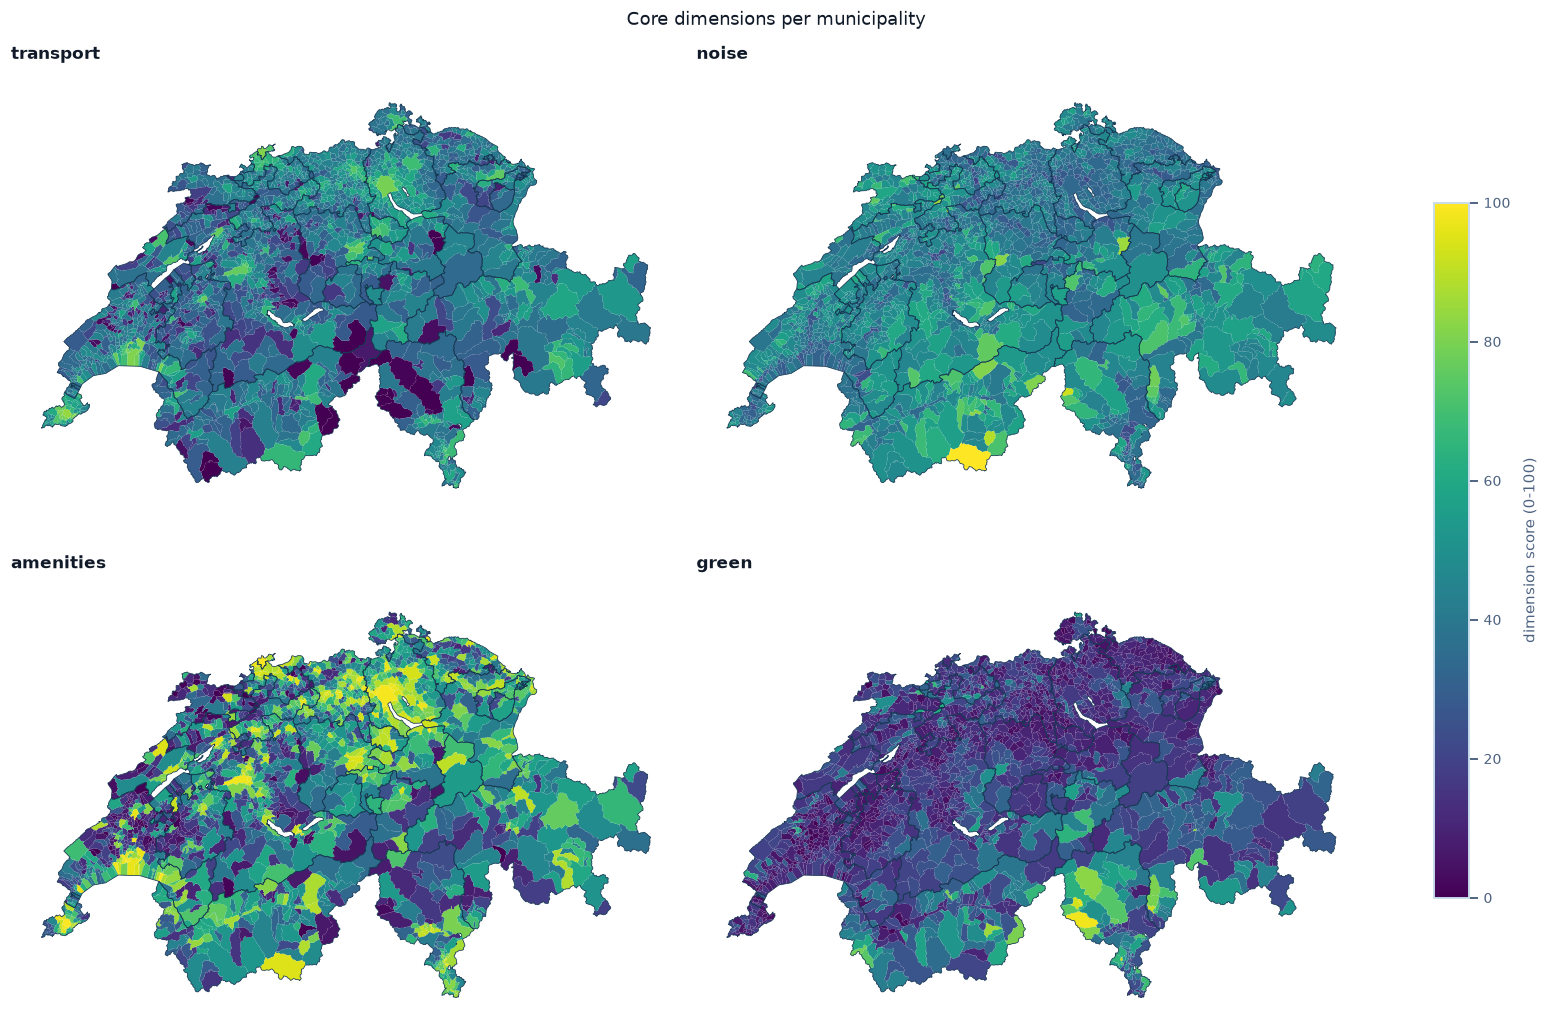

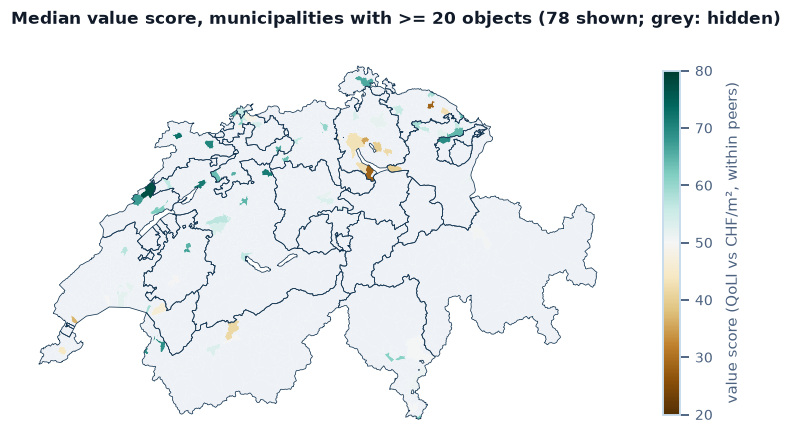

In [21]:
canton_shapes = admin_units[["canton", "geometry"]].dissolve("canton").simplify(150)
muni_shapes = admin_units.set_index("municipality_id").geometry.simplify(100)


def style_map(ax: plt.Axes, title: str) -> None:
    canton_shapes.boundary.plot(ax=ax, color=COLORS["dark"], linewidth=0.5)
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title(title, fontsize=11)


fig, axes = plt.subplots(1, 2, figsize=(16, 5.6), layout="constrained")
order = np.argsort(qoli_h.to_numpy())
axes[0].scatter(hect["east"].to_numpy()[order], hect["north"].to_numpy()[order], s=0.15,
                c=qoli_h.to_numpy()[order], cmap="viridis", vmin=20, vmax=80, rasterized=True)
style_map(axes[0], f"QoLI core per inhabited hectare ({len(hect):,} hectares)")
frame = muni_shapes.to_frame("geometry").join(muni["qoli"])
frame.plot(ax=axes[1], column="qoli", cmap="viridis", vmin=20, vmax=80, linewidth=0,
           missing_kwds={"color": "#EEF2F6"})
style_map(axes[1], "QoLI core per municipality (population-weighted)")
fig.colorbar(plt.cm.ScalarMappable(plt.Normalize(20, 80), "viridis"), ax=axes, shrink=0.8,
             label="QoLI core (0-100)")
save_fig(fig, "qoli_map", paths.figures)
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 9.5), layout="constrained")
for ax, dim in zip(axes.flat, DIMS_CORE, strict=False):
    muni_shapes.to_frame("geometry").join(muni[dim]).plot(
        ax=ax, column=dim, cmap="viridis", vmin=0, vmax=100, linewidth=0,
        missing_kwds={"color": "#EEF2F6"})
    style_map(ax, dim)
fig.colorbar(plt.cm.ScalarMappable(plt.Normalize(0, 100), "viridis"), ax=axes, shrink=0.7,
             label="dimension score (0-100)")
fig.suptitle("Core dimensions per municipality")
save_fig(fig, "qoli_dimension_maps", paths.figures)
plt.show()

fig, ax = plt.subplots(figsize=(9, 5.8))
vframe = muni_shapes.to_frame("geometry").join(value_published["median_value"])
vframe.plot(ax=ax, column="median_value", cmap="BrBG", vmin=20, vmax=80, linewidth=0,
            missing_kwds={"color": "#EEF2F6"})
style_map(ax, f"Median value score, municipalities with >= {MIN_MAP_CELL} objects "
              f"({len(value_published)} shown; grey: hidden)")
fig.colorbar(plt.cm.ScalarMappable(plt.Normalize(20, 80), "BrBG"), ax=ax, shrink=0.7,
             label="value score (QoLI vs CHF/m², within peers)")
save_fig(fig, "qoli_value_map", paths.figures)
plt.show()

---

## 16. Exports and Experiment Tracking

- `models/qoli_spec.json`: indicator definitions, normalisation bounds, dimensions and default
  weights; together with `QoliLayers` it scores any new address in the app on the same scale.
- `data/app/qoli_municipalities.parquet`: municipal dimension scores, core and extended index,
  for the map (public data only, no listings).
- `data/interim/qoli_objects.parquet`: object-level indicators, scores and value score for the
  price model and the app (stays local, contains listing ids).
- `docs/results/qoli_*.md` and `docs/fig/qoli_*.png`: tables and figures of the
  report.
- MLflow run `qoli_index` (stage `qoli`): weights, aggregation, normalisation, sources, coverage,
  rank stability, convergent validity and threshold shares.

In [22]:
spec = {
    "version": f"qoli-{SESSION_ID}",
    "reference": "inhabited hectares, BFS STATPOP 2021 (winsor 1 %/99 %)",
    "aggregation": "linear; equal weights within dimensions, user weights across dimensions",
    "default_weights": {"core": dict.fromkeys(DIMS_CORE, 1.0),
                        "extended": dict.fromkeys(DIMS_EXT, 1.0)},
    "indicators": [{"name": i.name, "dimension": i.dimension,
                    "higher_is_better": i.higher_is_better, "transform": i.transform,
                    "description": i.description, "index": "core" if i in CORE else "extended",
                    "lo": float(qoli_bounds.loc[i.name, "lo"]),
                    "hi": float(qoli_bounds.loc[i.name, "hi"])} for i in EXTENDED],
    "sources": {k: {"reference": s.reference, "file": s.filename} for k, s in SOURCES.items()},
}
spec_path = paths.models / "qoli_spec.json"
spec_path.write_text(json.dumps(spec, indent=2, ensure_ascii=False))

APP_DIR.mkdir(parents=True, exist_ok=True)
muni_out = muni.drop(columns=["units"]).rename(columns={"weight": "population"})
muni_out.to_parquet(APP_DIR / "qoli_municipalities.parquet")
obj_out = raw_obj.drop(columns=["noise_how"]).join(dims_ext_o.add_prefix("dim_")).assign(
    qoli=qoli_o, qoli_ext=qoli_ext_o, value_score=value, chf_per_m2=ppsqm)
obj_out.to_parquet(paths.data_interim / "qoli_objects.parquet")
(paths.results / "qoli_consistency.md").write_text(to_markdown(consistency, floatfmt=".3f") + "\n")
print(f"wrote {spec_path.name}, {len(muni_out):,} municipalities and {len(obj_out):,} objects")

metrics = {"coverage_objects": float(qoli_o.notna().mean()),
           "coverage_hectares": float(qoli_h.notna().mean()),
           "coverage_objects_extended": float(qoli_ext_o.notna().mean()),
           "n_municipalities": int(muni["qoli"].notna().sum()),
           "spearman_qoli_chf_m2": float(rho_price),
           "pca_pc1_share": float(pca.explained_variance_ratio_[0])}
metrics |= {f"{u}_{k}": float(v) for u, row in weight_sens.drop(columns="stable").iterrows()
            for k, v in row.items()}
metrics |= {f"alpha_{d}": float(a) for d, a in consistency["cronbach_alpha"].dropna().items()}
metrics |= {f"convergent_rho_{k}": float(v) for k, v in validity["rho"].items()}
metrics |= {f"robust_rho_{u}_{s}": float(v) for (u, s), v in robust["spearman"].items()}
metrics |= {f"threshold_pct_{k}": float(v) for k, v in thresholds["residents (%)"].items()}
with tracker.run("qoli_index", stage="qoli", tags={"session": SESSION_ID},
                 params={"indicators_core": ",".join(i.name for i in CORE),
                         "indicators_extension": ",".join(i.name for i in EXTENSION),
                         "weights": json.dumps(PROFILES["equal"]), "winsor": "0.01/0.99",
                         "normalisation": "min-max on inhabited hectares",
                         "aggregation": "linear; equal within, weights across dimensions",
                         "noise_facade_radius_m": 20, "green_radius_m": 300,
                         "sensitivity_draws": BUDGET["sensitivity_draws"],
                         "data_source": DATA_USED, "osm": osm is not None}):
    tracker.log_metrics(metrics)
    tracker.log_table(validity.reset_index(), "convergent_validity", index=False)
    tracker.log_table(robust.reset_index(), "specification_robustness", index=False)
    tracker.log_table(thresholds.reset_index(), "thresholds", index=False)
    tracker.log_artifact(spec_path)
    for name in ("qoli_map", "qoli_robustness", "qoli_convergent_validity"):
        tracker.log_artifact(paths.figures / f"{name}.png", artifact_path="figures")
print(f"tracked {len(metrics)} metrics")

wrote qoli_spec.json, 2,110 municipalities and 8,125 objects


tracked 53 metrics


---

## 17. Summary: Answer to RQ4, Limitations and Next Steps

In [23]:
summary = {
    "objects with a core QoLI": f"{qoli_o.notna().mean():.1%} of {len(objects):,}",
    "municipalities with a core QoLI": f"{muni['qoli'].notna().sum():,} of {len(admin_units):,}",
    "weight perturbation stable (objects / municipalities)":
        " / ".join(str(bool(weight_sens.loc[u, "stable"])) for u in weight_sens.index),
    "median ρ under weights (objects / municipalities)":
        " / ".join(f"{weight_sens.loc[u, 'spearman_median']:.3f}" for u in weight_sens.index),
    "lowest ρ of an alternative specification (municipalities)":
        f"{robust.loc['municipalities', 'spearman'].min():.3f} "
        f"({robust.loc['municipalities', 'spearman'].idxmin()})",
    "convergent criteria supporting validity":
        f"{int(validity['supports_validity'].sum())} of {len(validity)}",
    "Spearman(QoLI, CHF/m²)": f"{rho_price:+.2f}",
}
display(pd.Series(summary, name="result").to_frame())

,result
objects with a core QoLI,"100.0% of 8,125"
municipalities with a core QoLI,"2,110 of 2,110"
weight perturbation stable (objects / municipalities),False / False
median ρ under weights (objects / municipalities),0.926 / 0.949
lowest ρ of an alternative specification (municipalities),0.648 (without amenities)
convergent criteria supporting validity,2 of 4
"Spearman(QoLI, CHF/m²)",+0.28


**Answer to RQ4: partially.** A transparent quality-of-life index can be built from public data
without ground truth, but its validity can only be argued from several weaker pieces of
evidence, and they do not all point the same way:

1. **Construction** follows the OECD/JRC handbook with dated, citable sources; one
   pre-stated revision (parks) was triggered by the consistency check and is documented.
2. **Robustness** holds for normalisation and indicator details and on average for the weights
   (median ρ ≥ 0.93), but the pre-stated stability rule fails in the tail (5th percentile ρ ≈ 0.72
   to 0.74), because the dimensions trade off against each other. The ranking is a function of
   the weights, which is why users set them.
3. **Convergent validity** is supported by rent capitalisation and by the official
   accessibility data, not supported by vacancy, and contradicted by population growth, which in
   2011–2021 followed building land rather than location quality.

The index is therefore fit for its purpose in RentLens, *explaining* a location along four
transparent dimensions with user weights, but not for a single authoritative ranking of
municipalities.

**Limitations.**

- *Modelled, not measured exposures.* sonBASE and PolluMap are model outputs meant for statistical
  statements; the façade proxy (loudest cell within 20 m) is an approximation of the LSV
  assessment point, and the WHO comparison rests on an L<sub>den</sub> approximation.
- *Different reference years.* Noise 2021, land use 2013–2020, population 2021, air 2025,
  timetable 2026, vacancy 2026, tax 2018. The tax file is eight years old; rank changes between
  municipalities are slow, but the extended index should be refreshed once the ESTV publishes a
  newer municipal file.
- *Green means forest, woods and parks.* Farmland and alpine pasture are not counted, so
  villages surrounded by fields on the Plateau score low on green although they feel open;
  a variant with farmland would shift the green dimension towards rural places.
- *OSM completeness* varies by region; the BFS distance check measures how well it holds overall,
  not in every village.
- *Hectare vs address.* Municipal scores rest on hectare centres, apartments on their building
  coordinate; both use the same bounds, but a hectare centre is not a façade.
- *External validation is indirect.* Vacancy, growth and rents are also driven by supply,
  incomes and taxes. BILANZ/IAZI could not be obtained; a small resident survey (RQ5) would add
  the missing subjective view.

**Next steps.** Load `models/qoli_spec.json` and `data/app/qoli_municipalities.parquet` into the
Dash app (address → `QoliLayers.indicators` → normalised dimensions with the user's weights);
add the QoLI dimensions as candidate features in the price model only after checking that they
do not leak price information (they do not use rents, but the value score does); refresh the
OSM cache and the tax file before the final report.